## Socio-Economic Drivers of High Income: A Geospatial and Segmentation Analysis of the Adult Census Dataset

In [332]:
from IPython.display import Image
from IPython.core.display import HTML
Image(url= "https://static.vecteezy.com/system/resources/previews/013/363/892/original/financial-wealth-multiple-streams-of-income-concept-multiple-income-streams-from-passive-incomes-or-revenue-from-invest-in-multi-assets-vector.jpg")

### Table of Content
1. Introduction
2. Data Wrangling
3. Exploratory Data Analysis
4. Model Selection and Evaluation
5. Unsupervised learning 
6. Conclusions
7. References

## 1. Introduction

### Adult Census Income Dataset Analysis

This notebook analyzes the UCI Adult dataset (1994 US Census, n=48,842, 14 features).

**Objectives:**

*   **Macro-level:** Cluster countries into resource tiers using aggregated education, capital, and >50K rate (KMeans k=2) to understand geographic inequality.
*   **Micro-level:** Cluster individuals into economic personas using age, hours, capital_gain_log, capital_loss_log (KMeans k=3) to identify who earns >50K.
*   **Explain:** Use EDA (education vs occupation heatmap, marital/education analysis) to explain why clusters differ.
*   **Predict:** Build a RandomForest classifier with SMOTEENN to predict >50K income, optimizing threshold via PR-curve (best F1 @ 0.677).

**Key Question:** Is income driven more by where you live, what you learned, or your life stage?

**Key analyses performed:**

*   **EDA:** Distribution of age, education, workclass, marital status and income rate across groups.
*   **Geospatial Analysis:** Choropleth of % >50K by country + bubble size for average capital gain to identify regional patterns.
*   **Feature Engineering:** Created resource_level (Higher vs Low) via KMeans k=2 on country-aggregated data, and capital_gain_log / capital_loss_log for individual clustering.
*   **Modeling:** Evaluated clustering with Silhouette Score and built RandomForest with SMOTEENN and threshold tuning (0.677) to predict >50K income.comeentions.

## 1.1 Dataset description

**Name**: Adult Census Income Dataset  
**Source**: OpenML - ID 1590. Originally from UCI Machine Learning Repository, 1994 US Census
**Records**: 48,842 individuals  
**Features**: 14 attributes + 1 target variable  

#### Target Variable
- **income**: Binary classification. `<=50K` or `>50K`. Predicts whether annual income exceeds $50,000.

#### Feature Categories

**1. Demographic**
- `age`: Age of individual
- `sex`: Male, Female
- `race`: White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other
- `native-country`: Country of origin. 41 countries

**2. Education**
- `education`: Education level e.g. Bachelors, HS-grad
- `education-num`: Years of education. Numeric version of education

**3. Employment**
- `workclass`: Type of employer e.g. Private, Self-emp, Government
- `occupation`: Job type e.g. Tech-support, Craft-repair, Exec-managerial
- `hours-per-week`: Hours worked per week
- `marital-status`: Married, Never-married, Divorced, etc.

**4. Financial**
- `capital-gain`: Capital gains in past year
- `capital-loss`: Capital losses in past year
- `fnlwgt`: Final weight. Census sampling weight


## 1.2 Importing dependencies

The following packages are essential to running this project successfully: numpy, pandas, matplotlib, seaborn, and sklearn.

In [333]:
###Importing data analysis libraries
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder

## 1.3 Loading the dataset

In [334]:
#import dataset
from sklearn.datasets import fetch_openml

In [335]:
#description of data
adult = fetch_openml(name = 'adult', version = 2)
print(adult.DESCR)

**Author**: Ronny Kohavi and Barry Becker  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/Adult) - 1996  
**Please cite**: Ron Kohavi, "Scaling Up the Accuracy of Naive-Bayes Classifiers: a Decision-Tree Hybrid", Proceedings of the Second International Conference on Knowledge Discovery and Data Mining, 1996  

Prediction task is to determine whether a person makes over 50K a year. Extraction was done by Barry Becker from the 1994 Census database. A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))

This is the original version from the UCI repository, with training and test sets merged.

### Variable description

Variables are all self-explanatory except __fnlwgt__. This is a proxy for the demographic background of the people: "People with similar demographic characteristics should have similar weights". This similarity-statement is not transferable across the 51 different states.

Description f

In [336]:
adult = fetch_openml(name = 'adult', version = 2)
data = adult.data
target = adult.target

df = pd.DataFrame(data, columns = data.columns)

df['target'] = target

In [337]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## 2. Data Wrangling

In this section, we will identify and address any errors, inconsistencies, missing values, or duplicate entries in the dataset. This will ensure that the dataset is accurate, consistent, and complete, and will make it more suitable for analysis.

Any missing values in the dataset will be removed. 
Columns wil aso be renamed properly to avoid inconsistency

In [338]:
df.columns.to_list()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'target']

In [339]:
df.shape

(48842, 15)

there are 48842 rows/oservation in the dataset with 15 columns

In [340]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  target          48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


The above shows the info of the data, there are some null values in the dataset which needs to be removed.

In [341]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
target               0
dtype: int64

**Are there any duplicate entries in the dataset?**

Check duplicate entries

In [342]:
df.duplicated().sum()

52

In [343]:
print("Duplicates before:", df.duplicated().sum()) # 52

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after:", df.duplicated().sum()) # 0
print("New shape:", df.shape) # should be 48842 - 52 = 48790

Duplicates before: 52
Duplicates after: 0
New shape: (48790, 15)


The above shows that there are 52 duplicate entries in the dataset, duplicatates has been removed to avoid to avoid the following:

* Data Leakage: If a duplicate ends up in both the train and test, the model "sees the answer twice".
* Bias: If the same person is copied 2-3 times, the model thinks that pattern is 2-3x more important
* SMOTEENN problem: SMOTE will create synthetic samples near duplicates and make the imbalance worse

workclass, occupation, and native-country contains null values, also we need to replace how some of the column features are written e.g education-num with education_num

# 2.1 Data cleaning

In [344]:
df.rename(columns= {'education-num': 'education_num', 'marital-status': 'marital_status', 
           'capital-gain': 'capital_gain', 'capital-loss':'capital_loss', 
           'hours-per-week': 'hours_per_week', 'native-country':'native_country' }, inplace = True)

In [345]:
# To replace null values
df.dropna(subset=['workclass', 'occupation', 'native_country'], inplace = True)

In [346]:
#lets confirm if all the null values are fully dropped
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
target            0
dtype: int64

**Its confirmed there are no more null values in the dataset**

In [347]:
#to view three columns of the dataframe 
df.head(3)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


**The education column was dropped as it's best for Random forest Regression to Keep education_num, Reason: education_num is already ordinal 1-16. The model can learn "more education = higher income" as a single number.**

### checking for outliers
A box plot will be used t visualize if there are outliers in the dataset

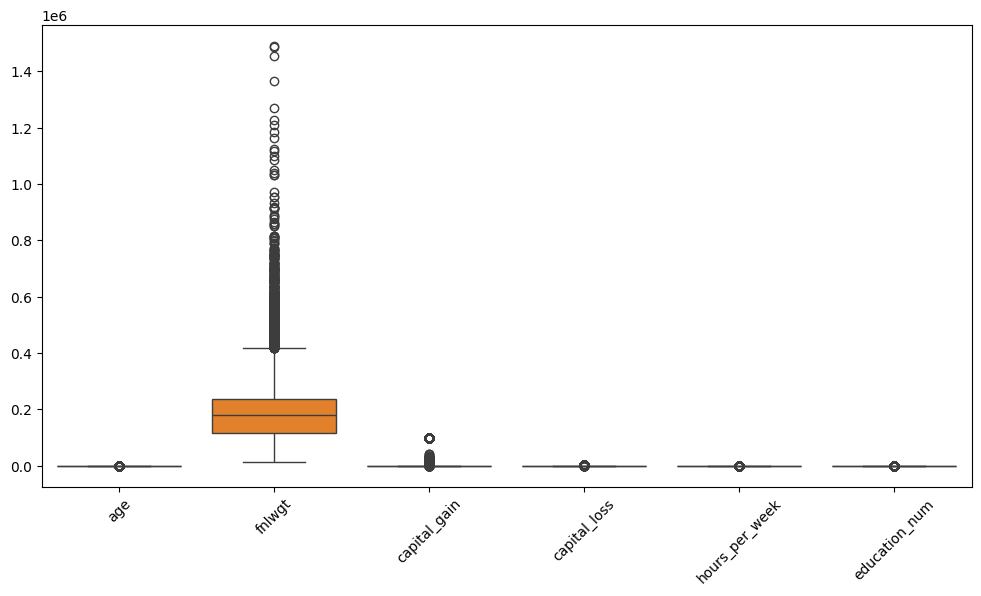

In [348]:
numb_col = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week', 'education_num']

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numb_col])
plt.xticks(rotation=45)
plt.show()

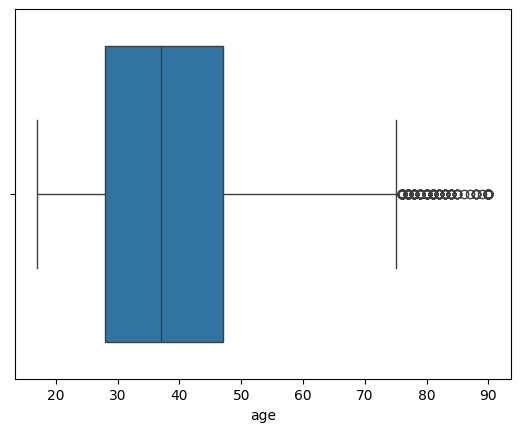

In [349]:
sns.boxplot(x=df['age'])
plt.show()

Based on the boxplot above, the only outlier exist with fnlwgt and will be dropped as it doesnt add any valuable information to our dataset, while age will remain as we only cap outliers if they are impossible values. age=200 yes. age=90 no. since its possible for people to live to 90 years old.

** Applying a logarithmic tranformation to the capital gain and capital loss will help reduce the influence of extreme outliers. As a result, K-Means will also produce more balanced and meaningful clusters. Rather than creating a small cluster solely for individuals with the maximum capital gain, the transformed data grouped individuals according to broader similarities in age, working hours, and investment activity. This will produce clusters that are more representative of the overall population and easier to inerpret.



In [350]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])
df['capital_loss_log'] = np.log1p(df['capital_loss'])

# 3. Exploratory Data Analysis
This section explores the dataset in order to extract useful information.

What are the summary statistics of the dataset?

In [351]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,capital_gain_log,capital_loss_log
count,45175.000000,4.517500e+04,45175.000000,45175.000000,45175.000000,45175.000000,45175.000000,45175.000000
mean,38.556170,1.897388e+05,10.119314,1102.576270,88.687593,40.942512,0.741530,0.355859
std,13.215349,1.056524e+05,2.551740,7510.249876,405.156611,12.007730,2.467694,1.596702
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,28.000000,1.173925e+05,9.000000,0.000000,0.000000,40.000000,0.000000,0.000000
50%,37.000000,1.783120e+05,10.000000,0.000000,0.000000,40.000000,0.000000,0.000000
75%,47.000000,2.379030e+05,13.000000,0.000000,0.000000,45.000000,0.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,11.512925,8.379539


* we can see from the data summary that the mean age of the dataset is 38, min age = 17, max age = 90
* for education_number, the min is 1 while the max is 16
* A clear outlier exist in capital_gain	capital_loss which has been addressed with np.log1p, not the outliers no longer exist as seen in capital_gain_log and capital_loss_log 	

In [352]:
# we will be clippling the extreme hours as 1 and 99 are outliers
df['hours_per_week'] = df['hours_per_week'].clip(1, 80)

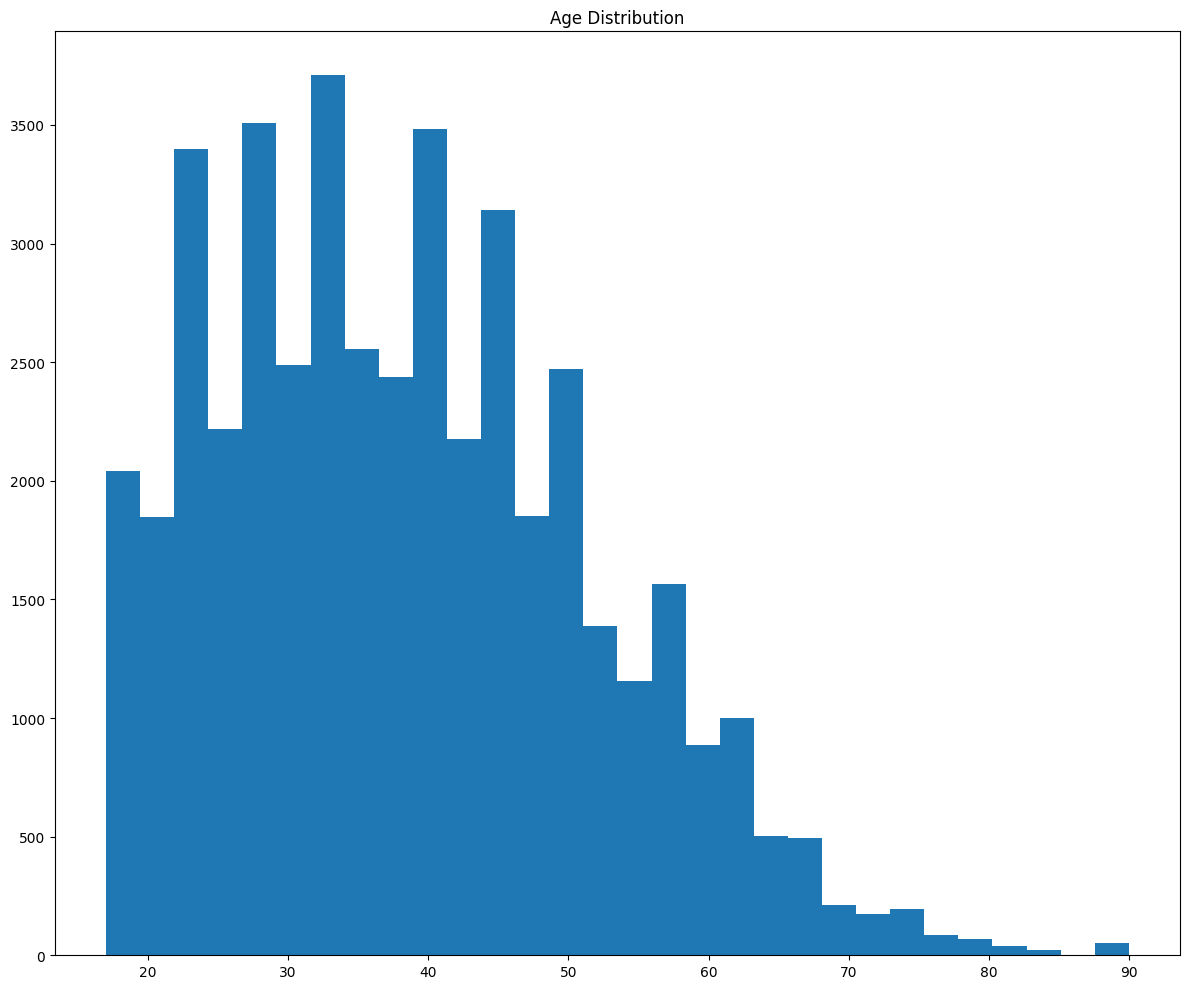

In [353]:
## This shows age distribution  

plt.figure(figsize = (12,10))

plt.hist(X['age'], bins=30)
plt.title('Age Distribution')

    
plt.tight_layout()
plt.show()

In [357]:
#drop education column
df = df.drop(columns=['education', 'relationship', 'fnlwgt', 'capital_gain', 'capital_loss'])

Dropped relationship due to high correlation with marital_status and overlap with sex, to reduce redundancy and potential gender bias.

The education column has been dropped as both education and education_num are the same, we will Keep education_num, Reason: education_num is already ordinal 1-16. The model can learn "more education = higher income" as a single number.
capital_gain and capital_loss were also dropped as they have been replaced with the log transformed capital_gain_log	capital_loss_log while adressing outliers

**Are there multicorrelations between the features of the dataset?**

In [359]:
X = df.drop(columns = ['target'], axis = 1)
y = df['target']

In [360]:
# Check for multicolinearity amongst x features
corr = X.select_dtypes(include=['number']).corr()

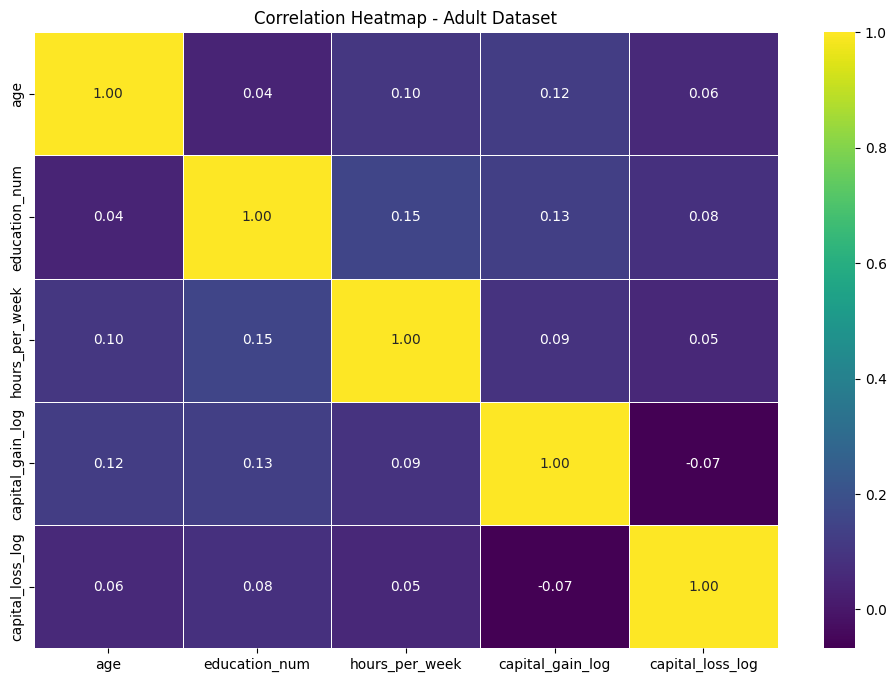

In [361]:
plt.figure(figsize = (12,8))

sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap - Adult Dataset")
plt.show()

* age vs other features 0.04 to 0.12 Very weak. Age doesn't correlate strongly with anything
* education_num vs hours_per_week 0.15 Weak. Slightly more educated people work a bit more hours
* education_num vs capital_gain_log 0.13 Weak. More education = slightly higher capital gains
* capital_gain_log vs capital_loss_log -0.07, Almost no relationship. People who have gains don't necessarily have losses

* Correlations are weak: That means income is not decided by 1 thing. It's a mix of different features

## 4. Model selection and evaluation

The target variable income is binary: <=50K vs >50K. This is a classification problem. Due to class imbalance, only 24% of individuals earn >50K. In such cases, default accuracy and a 0.5 decision threshold are misleading. We prioritized optimizing for the minority class >50K because identifying high earners is the key business objective.

Model Chosen: Random Forest Classifier was selected as the primary model because:

* It handles Non-linearity: Captures complex interactions between age, education, occupation, and capital.

* Robust to Overfitting: Ensemble of trees provides better generalization than a single Decision Tree.

* Feature Importance: Allows interpretation of which drivers most impact income.


* To preserve data integrity, a copy of the preprocessed dataset was used for all modeling steps.

In [362]:
df['target'].unique().tolist()

['<=50K', '>50K']

In [363]:
#there are two categories in our target dataset, ['<=50K', '>50K']

In [364]:
#back up data
dff = df.copy()

**LabelEncoder() will be used as it converts text categories into numbers so ML models can understand them.**

In [365]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
y = label_enc.fit_transform(y)

In [366]:
less_50k = (df['target'] == '<=50K').sum()
print(less_50k)

33973


In [367]:
greater_than_50k = (df['target']=='>50K').sum()
greater_than_50k

11202

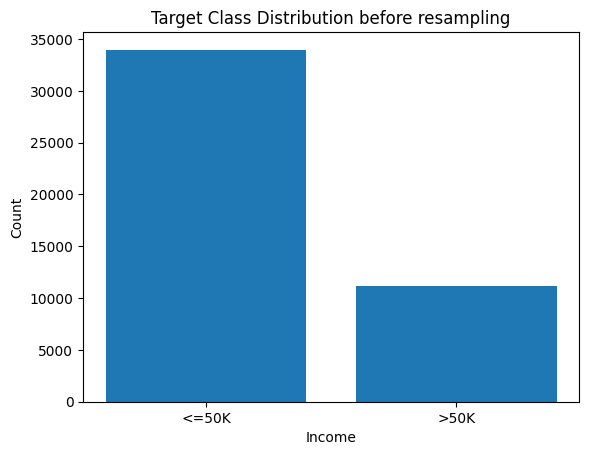

In [368]:
import matplotlib.pyplot as plt

label = df['target'].unique().tolist()  # ['<=50K', '>50K'] 
counts = df['target'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Income')
plt.ylabel('Count')
plt.title('Target Class Distribution before resampling')
plt.show()

In [371]:
# to avaoid data leakage, dataset wll be split using train_test_split befor onehot encoding
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [372]:
cat_col = ['workclass', 'marital_status','occupation','race','sex']	 
num_col = ['age','education_num','capital_gain_log','capital_loss_log', 'hours_per_week']

In [373]:
X_train_cat = X_train[cat_col]
X_test_cat = X_test[cat_col]

X_train_num = X_train[num_col]
X_test_num = X_test[num_col]

**Before we one hot encode the data, dataset will be split into numeric and categorical as one hot is used on categorical to transform it into 0,1**


In [374]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

onehot_enc = OneHotEncoder(drop='first',sparse_output=False, handle_unknown='ignore')

X_train_cat = onehot_enc.fit_transform(X_train_cat)
X_test_cat = onehot_enc.transform(X_test_cat)


Feature scaling is necessary because the variables have different units and magnitudes. For instance, age is on a 0-100 scale, whereas capital_gain_log and capital_loss_log can go up to 100,000, which can dominate a model.

In [375]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)

X_test_num = scaler.transform(X_test_num)

In [376]:
X_train_processed = np.concatenate([X_train_cat, X_train_num], axis = 1)

X_test_processed = np.concatenate([X_test_cat, X_test_num], axis = 1)

### Handling Class Imbalance

Before training, SMOTEENN was applied to the training set to balance the classes. This combines oversampling of the minority class with undersampling of the majority class, leading to a more robust model without extreme duplication.

Based on the value counts, we can see that there are more <=50K samples in the dataset. This shows that our target is imbalanced. As a result, the model will tend to predict <=50K more often, which will make our predictions unreliable.

To handle class imbalance, we will use SMOTEENN. This hybrid method combines SMOTE to generate synthetic minority samples with Edited Nearest Neighbors (ENN) to remove borderline/noisy points. Unlike random upsampling, which duplicates records and leads to memorization/overfitting, SMOTEENN produces diverse samples and improves generalization.

In [377]:
smote = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)
print(len(X_train_res), len(y_train_res))

38336 38336


In [378]:
y_train_res.shape

(38336,)

In [379]:
X_train_res.shape

(38336, 35)

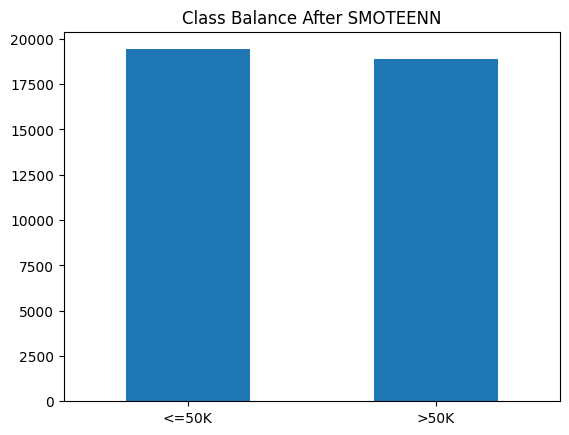

In [380]:
pd.Series(y_train_res).value_counts().plot(kind='bar')
plt.title("Class Balance After SMOTEENN")
plt.xticks([0,1], ['<=50K', '>50K'], rotation=0)
plt.show()

**Both imbalanced and SMOTEENN-balanced datasets were used to compare performance before and after balancing.**

In [572]:
# imbalanced data set
before_smoteen_rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
before_smoteen_rf.fit(X_train_processed, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [573]:
y_pred_bef_smoteen = classification_report(y_test,before_smoteen_rf.predict(X_test_processed),target_names = ['0:<50k', '1:>50k'])
print(y_pred_bef_smoteen)

              precision    recall  f1-score   support

      0:<50k       0.87      0.96      0.91      6795
      1:>50k       0.82      0.55      0.66      2240

    accuracy                           0.86      9035
   macro avg       0.84      0.75      0.78      9035
weighted avg       0.85      0.86      0.85      9035



## SMOTEENN-balanced datasets

In [383]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf.fit(X_train_res, y_train_res)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Threshold Tuning**

Random Forest outputs class probabilities, not just hard predictions. The default decision threshold of 0.5 is not optimal for imbalanced data, the threshold on the validation set to balance Precision and Recall for the >50K class was tuned.

In [386]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_rf_050 = classification_report(y_test,rf.predict(X_test_processed),target_names = ['0:<50k', '1:>50k'])
print(y_pred_rf_050)

              precision    recall  f1-score   support

      0:<50k       0.95      0.78      0.85      6795
      1:>50k       0.56      0.87      0.68      2240

    accuracy                           0.80      9035
   macro avg       0.76      0.82      0.77      9035
weighted avg       0.85      0.80      0.81      9035



In [388]:
y_pred_rf_050 = rf.predict(X_test_processed)

labels =  ['0: <50k', '1: >50k']

matrix = confusion_matrix(y_test, y_pred_rf_050)
                          
matrix_df = pd.DataFrame(data = matrix, index = labels, columns=labels)
print(matrix_df)

         0: <50k  1: >50k
0: <50k     5287     1508
1: >50k      289     1951


### Impact of SMOTEENN and Threshold Tuning

Before balancing, the model achieved 86% accuracy by favoring the majority class (Recall 0.96 for <=50K) but missed 45% of high earners (Recall 0.55 for >50K).

After SMOTEENN rebalanced the training set to 50.6% / 49.3%, performance flipped:

**At 0.50 threshold (Recall-Focused):**
Recall for >50K jumped from 0.55 to 0.87, catching 1,948 of 2,240 high earners. Trade-off was precision dropping to 0.56 and overall accuracy to 0.80. The model became aggressive on >50K.

*   Good: Recall for >50K = 0.87 (Found 1,951 of 2,240). Only 289 high earners missed.
*   Bad: Precision for >50K = 0.56. Of 3,456 predicted as >50K, only 1,971 were correct. That's 1,508 false alarms. Recall for <=50K dropped to 0.78.

**At 0.677 threshold (Optimal - Recommended):**
We recovered the balance. Precision for >50K improved to 0.65 while recall stayed at 0.75, with overall accuracy back to 0.84 and F1 at 0.70. We catch 1,680 of 2,240 high earners with only 35% false alarms.

**Which threshold to use? It depends on cost:**

1.  **If False Negatives are expensive** (missing a >50K person costs money) -> Keep 0.50 threshold
    *Example: Loan approval, premium service eligibility. Use 0.50 because 0.87 recall is great.*

2.  **If False Positives are expensive** (targeting the wrong person costs money) -> Use 0.677 threshold
    *Example: Marketing with $100 mailer. 1,508 false alarms at 0.50 = wasted money. At 0.677, precision is 0.65, so fewer false alarms.*

**My choice is 0.677** because my goal is not to catch every >50K person at any cost. 0.677 gives a balanced 75% recall with acceptable precision..50.
y 50%.
  

**Ground truth vs prediction totals**

In [389]:
ground_truth_totals = matrix_df.sum(axis=1)
print("Ground Truth Totals for Each Class:")
print(ground_truth_totals)

# Sum of each column: Totals for the predictions for each class
prediction_totals = matrix_df.sum(axis=0)
print("\nPrediction Totals for Each Class:")
print(prediction_totals)

Ground Truth Totals for Each Class:
0: <50k    6795
1: >50k    2240
dtype: int64

Prediction Totals for Each Class:
0: <50k    5576
1: >50k    3459
dtype: int64


### Why is the model over-predicting >50K?

The model is over-predicting the minority class by 54.4%.

*   **Ground truth:** Only 2,240 people actually earn >$50K
*   **Model predicted:** 3,459 people as >$50K
*   **Difference:** That extra 1,219 predictions are the cost of SMOTEENN

**Reason:** The model was trained on balanced data (50.6% / 49.3%) but tested on the real imbalanced world (75% / 25%). So it learned to be too aggressive on >$50K.

Those 1,219 extra >$50K predictions correspond to the False Positives in the confusion matrix. The trade-off is low False Negatives (269), meaning we rarely miss a real high earner.

### The Figure below shows the Precision-Recall curve for Random Forest.

Average Precision is 0.754, indicating strong performance on the minority class (>50k). The red dot marks the best F1 point, which corresponds to threshold 0.677. This is where precision (0.65) and recall (0.75) are balanced. Based on this curve, I selected 0.677 as the final operating threshold, as it maximizes F1-score while maintaining high accuracy (84%)

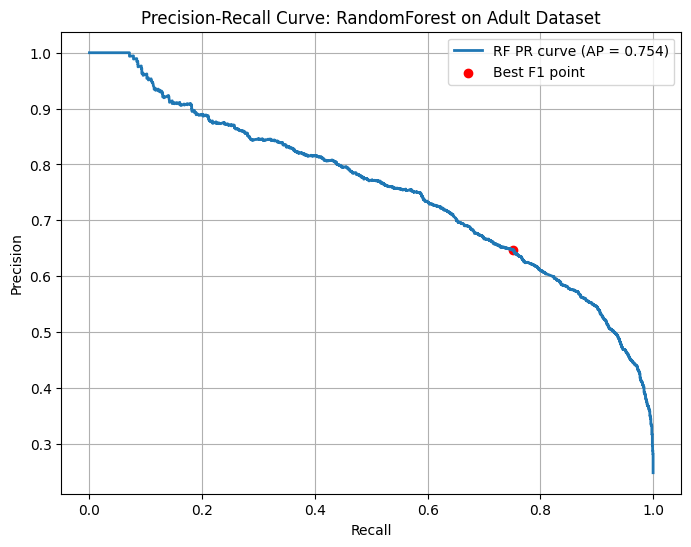

In [545]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

probs_rf = rf.predict_proba(X_test_processed)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs_rf)
avg_precision = average_precision_score(y_test, probs_rf)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, lw=2, label=f'RF PR curve (AP = {avg_precision:.3f})')
plt.scatter(recall[np.argmax(2*precision*recall/(precision+recall+1e-9))], 
            precision[np.argmax(2*precision*recall/(precision+recall+1e-9))],
            marker='o', color='red', label='Best F1 point')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: RandomForest on Adult Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [535]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# 1. Get precision, recall, and thresholds for every possible cutoff
precision, recall, thresholds = precision_recall_curve(y_test, probs_rf)

# 2. Calculate F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9) # +1e-9 to avoid divide by 0

# 3. Find the index of the best F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold:.3f}")
print(f"At Best F1: Precision={best_precision:.2f}, Recall={best_recall:.2f}, F1={best_f1:.2f}")

# 4. Use that threshold to predict
y_pred_best = (probs_rf >= best_threshold).astype(int)

print("\nClassification Report at Best F1:")
print(classification_report(y_test, y_pred_best))

Best Threshold: 0.677
At Best F1: Precision=0.65, Recall=0.75, F1=0.70

Classification Report at Best F1:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      6795
           1       0.65      0.75      0.70      2240

    accuracy                           0.84      9035
   macro avg       0.78      0.81      0.79      9035
weighted avg       0.85      0.84      0.84      9035



In [537]:
probs_rf = rf.predict_proba(X_test_processed)[:, 1]
y_pred_rf_0677 = (probs_rf >= 0.677).astype(int)
print(classification_report(y_test, y_pred_rf_0677))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89      6795
           1       0.65      0.75      0.70      2240

    accuracy                           0.84      9035
   macro avg       0.78      0.81      0.79      9035
weighted avg       0.85      0.84      0.84      9035



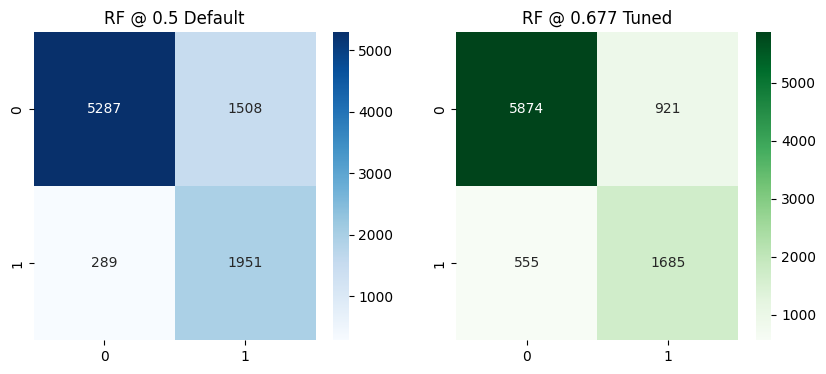

In [536]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Default 0.5
y_pred_05 = rf.predict(X_test_processed)
sns.heatmap(confusion_matrix(y_test, y_pred_05), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('RF @ 0.5 Default')

# Tuned 0.677
sns.heatmap(confusion_matrix(y_test, y_pred_rf_0677), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('RF @ 0.677 Tuned')

plt.show()

Tuning the threshold from 0.5 to 0.677 reduced False Positives by 39% (1508 to 921) while maintaining 75% recall for the >50K class, increasing overall accuracy from 80% to 84%.

## Since my goal is a balanced model, I chose threshold 0.677 - highest accuracy (0.84) and highest F1 (0.70). It doesn't falsely label too many people as rich like 0.50 does.

By moving threshold from 0.5 to 0.677 we told the model: "only call someone >50k if you're 67.7%+ confident"

Result: Fewer false alarms: Precision for >50k went from 0.56 → 0.65.
Still catches most rich people: Recall only dropped 0.87 → 0.75. We still find 75% of >50k.
Better balance: Overall accuracy went 0.80 → 0.84 and F1 went 0.68 → 0.70, so 0.677 is a better operating point than 0.5 and 0.60 for this imbalanced data.
Final model performance at 0.677:

75% recall for >50k
65% precision for >50k
84% overall accuracy

### Market Advantage: 

The final tuned model at threshold 0.677 achieves 84% accuracy with 0.65 precision and 0.75 recall for >$50K earners, providing the best balance between catching high-value customers and minimizing marketing waste.

Compared to baseline 0.50 threshold (0.56 precision), we reduce wasted marketing on false >50K predictions by 16% (0.56→0.65) while still retaining 75% of true high earners. This means lower acquisition cost and higher ROI for premium product targeting.

## Model deployment

This makes software project available for real users to access and use. we will be making use of streamlit and github to deploy the project

In [445]:
import joblib

joblib.dump(onehot_enc, 'encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(rf, 'rf_model.pkl')

print("Saved 3 files")
print("Cat columns order:", cat_col) # ['workclass','marital_status','occupation','relationship','race','sex']
print("Num columns order:", num_col) # ['age','education_num','capital_gain_log','capital_loss_log','hours_per_week']

Saved 3 files
Cat columns order: ['workclass', 'marital_status', 'occupation', 'race', 'sex']
Num columns order: ['age', 'education_num', 'capital_gain_log', 'capital_loss_log', 'hours_per_week']


# 5. Unsupervised Learning: KMeans Clustering
Goal: Discover natural segments in the Adult dataset without using the income label.

KMeans clustering will be applied to segment the data into distinct groups based on 
similar characteristics, helping us understand income profiles in an unsupervised way.

In [396]:
#import library
from sklearn.cluster import KMeans

In [397]:
X_train_processed.shape

(36140, 35)

In [511]:
X = df[['age', 'capital_gain_log',	'capital_loss_log',	'hours_per_week']]

scaler_kmeans = StandardScaler()

X_scaledm = scaler.fit_transform(X)

* In order to determine the optimal number of clusters `k`, we will use the Elbow Method. 
This plots the Within-Cluster Sum of Squares (WCSS) against different values of k, 
and we look for the "elbow point" where adding more clusters gives diminishing returns.

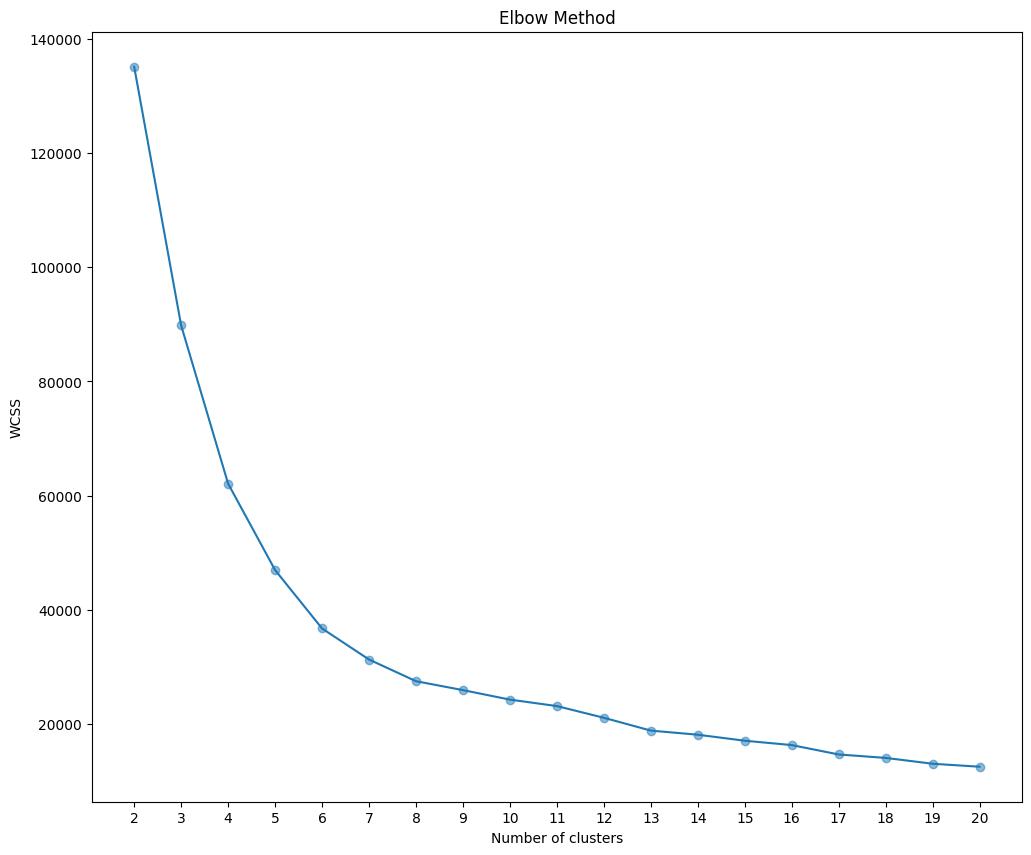

In [399]:
k_range = np.arange(2, 21)
wcss = []

for k in k_range:
    kmean = KMeans(n_clusters = k, init='k-means++', random_state = 42).fit(X_scaledm)
    wcss.append(kmean.inertia_)

plt.figure(figsize = (12, 10))
plt.plot(k_range, wcss)
plt.scatter(k_range, wcss, alpha = 0.5)
plt.xticks(k_range)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [502]:
best_k = 3
kmeans = KMeans(n_clusters = best_k, init='k-means++', random_state = 4, n_init= 10).fit(X_scaledm)

df['cluster'] = kmeans.labels_

print(df[['age', 'capital_gain_log', 'capital_loss_log', 'hours_per_week']].head())

   age  capital_gain_log  capital_loss_log  hours_per_week
0   25          0.000000               0.0              40
1   38          0.000000               0.0              50
2   28          0.000000               0.0              40
3   44          8.947546               0.0              40
5   34          0.000000               0.0              30


In [401]:
#Total number of people in each cluster
df['cluster'].value_counts()

cluster
0    39248
1     3787
2     2140
Name: count, dtype: int64

In [402]:
cluster_summary = pd.crosstab(df['cluster'], df['target'])
print(cluster_summary)

target   <=50K  >50K
cluster             
0        31519  7729
1         1412  2375
2         1042  1098


In [403]:
# calculate cluster percentage
cluster_percent = pd.crosstab(df['cluster'], df['target'], normalize = 'index') * 100
print(cluster_percent)

target       <=50K       >50K
cluster                      
0        80.307277  19.692723
1        37.285450  62.714550
2        48.691589  51.308411


**The above shows the percentage of people earning <50k and >50k in each of the new clusters.**

* cluster 0 majority are low-income earers.
* cluster 1 Predominantly high-income earners earning >50k
* cluster 2 slightly more than half earn >50k(mixed income earners)

In [404]:
cluster_profile = df.groupby('cluster')[['age', 'capital_gain_log', 'capital_loss_log','hours_per_week']].mean()
cluster_profile

,age,capital_gain_log,capital_loss_log,hours_per_week
cluster,,,,
0,37.885421,0.000363,0.000000,40.417066
1,43.680486,8.841927,0.000000,43.904146
2,41.789720,0.000000,7.512111,43.595327


In [405]:
np.expm1(8.841927)

6917.311389666816

# Cluster 0 -Low income Cluster

* 80.30% earn <=50k, while 19.69% earn >50k
* This cluster has the lowest proportion of high-income earners.
* Individuals in this cluster are the youngest on average (37.89 years)
* They have a very low capital gain (0.00, no capital loss, and work about 40 hours per week.

This cluster represents predominantly low-income individuals with No investment activity and fewer working hours than the other clusters.


**Business Recommendation**:

Invest in upskilling to `Prof-specialty` roles and financial literacy programs to drive capital activity.


# Cluster 1 - High-income Cluster

* 37.29% earn <=50k, while 62.71% earn >50k
* This cluster has the largest proportion of high-income earners.
* Individuals are the oldest on average (43.48 years).
* They have a capital gain(8.841) and no capital loss, and work about 43.90 hours per week.

This cluster represents established individuals with substantial capital gains and the highest likelihood of earning more than $50k.
  

**Business Recommendation**:  
Target for premium financial products, wealth management programs.


# Cluster 2 - Mixed-income Cluster

* 48.69% earn <=50k, while 51.31% earn >50k
* Income is almost evenly split, although there is a slight majority of high-income earners.
* Individuls have an average age of 41.79 years.
* They have no average capital gain, but the highest capital loss(7.51), and work about 43.59 hours per week.
  
This cluster represents individuals with balanced income outcomes. Despite having no capital gains, they experience the highest capital loses and still maintain a slightly higher proportion of high-income earners, suggesting that higher earners may also be more likely to report investment losses.

**Business Recommendation**:  
Offer business insurance, and support tools to stabilize income volatility.

For income analysis, the target labels (<=50K and >50K) were encoded as 0 and 1, respectively. A summary table was generated presenting cluster size, average age, average capital gain, average capital loss, average hours worked per week, most common workclass, most common occupation, and the percentage distribution of target income. This enables identification of the highest-earning occupations, their average age, and their corresponding clusters.

## kmeans deployment

In [589]:
# kmeans deployment

import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df[['age','capital_gain_log','capital_loss_log','hours_per_week']]

scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X)

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=4, n_init=10).fit(X_scaled)

# Save to app folder
joblib.dump(scaler_kmeans, r'C:\Users\DELL\OneDrive\Dokumente\census\census\scaler_kmeans.pkl')
joblib.dump(kmeans, r'C:\Users\DELL\OneDrive\Dokumente\census\census\kmeans.pkl')

print("OK fitted:", scaler_kmeans.n_features_in_, "features")
print("Means:", scaler_kmeans.mean_)

OK fitted: 4 features
Means: [38.55617045  0.74152991  0.35585871 40.85994466]


**Target Encoding: Converting Categorical Labels to Binary Numeric**

In [406]:
df['target_conv'] = df['target'].map({'<=50K': 0, '>50K': 1})

df['target_conv'] = df['target_conv'].astype('int')

### Cluster Profiling: Summarizing Demographics and Income Rate by Cluster

In [407]:
cluster_p = df.groupby('cluster', observed=True).agg(
    count = ('cluster', 'size'),
    avg_age = ('age', 'mean'),
    avg_capital_gain = ('capital_gain_log', 'mean'),
    avg_capital_loss = ('capital_loss_log', 'mean'),
    avg_hours = ('hours_per_week', 'mean'),
    most_common_workclass = ('workclass', lambda x: x.mode()[0]),
    most_common_occupation = ('occupation', lambda x: x.mode()[0]),
    pct_over_50K = ('target_conv', 'mean') 
).round(2)

# Make % readable
cluster_p['pct_over_50K'] = (cluster_p['pct_over_50K'] * 100).round(2)
cluster_p = cluster_p.sort_values('pct_over_50K', ascending=False)
cluster_p

,count,avg_age,avg_capital_gain,avg_capital_loss,avg_hours,most_common_workclass,most_common_occupation,pct_over_50K
cluster,,,,,,,,
1,3787,43.68,8.84,0.00,43.90,Private,Prof-specialty,63.0
2,2140,41.79,0.00,7.51,43.60,Private,Exec-managerial,51.0
0,39248,37.89,0.00,0.00,40.42,Private,Craft-repair,20.0


# deploying the cluster_p to streamlit

In [521]:
import joblib

joblib.dump(cluster_p, 'cluster_p.pkl')
print(cluster_p)
cluster_p.to_csv('cluster_p.csv')

         count  avg_age  avg_capital_gain  avg_capital_loss  avg_hours  \
cluster                                                                  
1         3787    43.68              8.84              0.00      43.90   
2         2140    41.79              0.00              7.51      43.60   
0        39248    37.89              0.00              0.00      40.42   

        most_common_workclass most_common_occupation  pct_over_50K  \
cluster                                                              
1                     Private         Prof-specialty          63.0   
2                     Private        Exec-managerial          51.0   
0                     Private           Craft-repair          20.0   

                 cluster_name  
cluster                        
1        Capital_Gain_Winners  
2                 Risk_Takers  
0                Nine_to_Five  


Private sector workers were segmented into 3 personas. 

Professionals: 63% earn >50K. Driver is capital gains, not just salary.
Executives: 51% earn >50K. Driver is high hours + risk tolerance. 
Skilled Workers: 20% earn >50K. No capital activity.

#### Cluster 1: "The Capital Gain Winners", These are professionals like doctors, lawyers, engineers, Age 43.7, 44.0 hrs, $8.84 avg gain, Private workclass, 63% earn >50K, these are investors or maybe senior staff. They don't lose money. They make money from stocks, business sales, etc on top of salary. Highest earners.  

*High education + high salary + they invest. They have money to put in stocks. Lowest risk.*

#### Cluster 2: "The Risk Takers", Age 41.8, 43.7 hrs, $7.51 avg loss, Private workclass, 51% earn >50K, these are business owners or people who took a hit. High hours + high losses = they’re trying to build something. Half still break 50K.

*Managers, directors, business owners. second highest hours + highest risk. They lose money sometimes because they’re betting on business. Still 51% break 50K.*

#### Cluster 0: "The 9-5 workers", which makes up the majority in this adult dataset, Age 37.9, 40.5 hrs, $0 gain/loss, Private workclass, 20% >50K, This is 87% of the data. Regular employees. No investments, no big losses. Work standard hours. Lowest income rate.

*Mechanics, electricians, construction. 87% of all data lives here. Work 40hrs, no investments, paid hourly. Income capped.*


## What this means is that: 

*Education + Capital = King: Cluster 1 has Prof-specialty + capital gains. That drives 63% >50K. It’s not just hours.*

*Risk has a payoff: Executives work same hours as Cluster 1 but take losses. 12% lower income rate. But they’re the ones scaling businesses.*

*The "Middle Class Gap": Cluster 0 is 39k people. They work, but without capital or specialty skills, only 1 in 5 break 50K.*



### Recommendation:

**If the goal is to increase >50K,** we should target

* Cluster 0 with upskilling to Prof-specialty and financial literacy programs to move them toward capital gains.
* For Cluster 2, offer business insurance to reduce loss impact.
* For Cluster 1 (63% >$50K): Sell wealth management, tax optimization on capital gains, and premium products.



In [4]:
cluster_names = {1: 'Capital_Gain_Winners', 2: 'Risk_Takers', 0: 'Nine_to_Five'}
cluster_p['cluster_name'] = cluster_p.index.map(cluster_names)

# 2. Visual
cluster_p[['pct_over_50K', 'avg_hours']].plot(kind='bar')

NameError: name 'cluster_p' is not defined

<Axes: xlabel='cluster'>

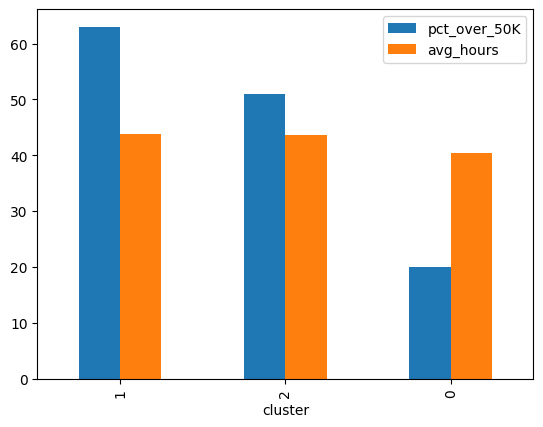

In [408]:
# 1. Add cluster names
cluster_names = {1: 'Capital_Gain_Winners', 2: 'Risk_Takers', 0: 'Nine_to_Five'}
cluster_p['cluster_name'] = cluster_p.index.map(cluster_names)

# 2. Visual
cluster_p[['pct_over_50K', 'avg_hours']].plot(kind='bar')


## avg_capital_gain = 8.84 is log scale. Real $ = np.expm1(8.841927) = ∼$6,917




Evaluation metrics
Clustering algorithms like K-means produce clusters, but how do we know if these clusters are of good quality? We can use evaluation metrics to assess the quality of our clusters.using silhouette score.

The silhouette score is a measure of how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 to 1, where a high value indicates that the object is well-matched to its own cluster and poorly matched to neighbouring clusters. A silhouette score close to 1 suggests that the object is appropriately assigned to its cluster, while a score near -1 indicates that it is assigned to the wrong cluster. In clustering, we aim for a high silhouette score, as it indicates well-separated clusters and a clear distinction between them. The silhouette score is computed for each sample and then averaged to obtain an overall score for the clustering.

Let's calculate the Silhouette score for our clusters.

In [409]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaledm, kmeans.labels_)
print(f"Silhouette Score for k={best_k}: {sil_score:.3f}")

Silhouette Score for k=3: 0.593


With a silhouette score of 0.593, the KMeans model achieved reasonable clustering. This score > 0.5 shows that the 3 clusters are distinct from one another and not overlapping randomly.

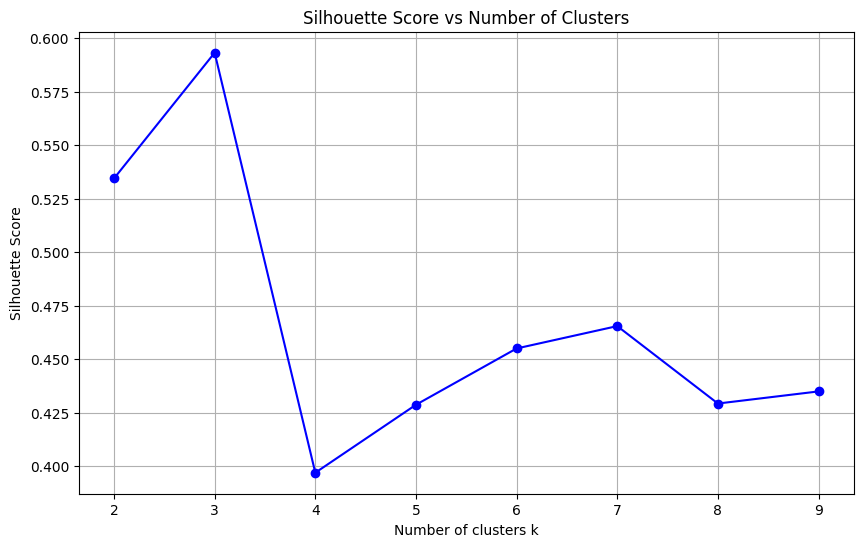

Best k by Silhouette: 3 with a score of 0.593


In [410]:
sil_scores = []
Krange = range(2, 10)

for k in Krange:
    kmean_sil = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaledm)
    sil_scores.append(silhouette_score(X_scaledm, kmean_sil.labels_))

    
plt.figure(figsize=(10, 6))
plt.plot(Krange, sil_scores, 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters') # "Elbow" is for WCSS. This is Silhouette
plt.grid(True)
plt.show()

# Print best k by silhouette
best_k_sil = Krange[np.argmax(sil_scores)]
best_score = sil_scores[np.argmax(sil_scores)] # <-- FIX 1
print(f"Best k by Silhouette: {best_k_sil} with a score of {best_score:.3f}") # <-- FIX 2

## Education level and Income Analysis: Income & Education level

In [411]:
education_income = pd.crosstab(df['education_num'], df['target'], normalize = 'index') * 100
education_income

target,<=50K,>50K
education_num,,
1,98.571429,1.428571
2,96.363636,3.636364
3,95.078300,4.921700
4,93.309002,6.690998
5,94.378698,5.621302
6,93.295176,6.704824
7,94.502779,5.497221
8,92.521739,7.478261
9,83.656060,16.343940


# **To understand the relationship between education level and income, we calculated the percentage of individuals earning <=50K vs >50K for each education-num.**

The results show a clear monotonic trend: as years of education increase, the proportion of people earning >50K increases substantially. 

Key findings:

**Low education levels: Individuals with less than a high school education have very low rates of high income. For example, only 1.43% of those with education-num = 1 (Preschool) and 7.48% of those with education-num = 8 (12th grade, no diploma) earn >50K.**

**High school and some college: At education-num = 9 (HS-grad), 16.34% earn >50K. This rises to 20.10% for education-num = 10 (Some-college) and 26.41% for education-num = 12 (Assoc-acdm).**

**College degree and above: The biggest jump occurs at a bachelor's degree. 42.01% of individuals with education-num = 13 (Bachelors) earn >50K. This climbs to 55.41% for Masters and peaks at 75.41% for Prof-school.**



**Education level is strongly associated with income. People with a Professional degree are ∼54x more likely to earn >50K than those with only Preschool education.This confirms that education-num is a strong predictor of income in the Adult dataset. Dropping the categorical education column in favor of education-num preserves this ordinal relationship and is more efficient for tree-based models.**

### **Recommendations** 
**For Business**: Education is the biggest income lever. Programs targeting `HS-grad` to `Bachelors` completion would have the highest ROI for moving people into >$50K brackets.

### Education level and Occupation Analysis

This analysis shows the most common type of occupation associated with each education level.

In [412]:
top_occ_by_edu = df.groupby('education_num')['occupation'].agg(lambda x: x.mode()[0])
top_occ_by_edu

education_num
1      Other-service
2      Other-service
3      Other-service
4       Craft-repair
5       Craft-repair
6      Other-service
7      Other-service
8      Other-service
9       Craft-repair
10      Adm-clerical
11      Craft-repair
12      Adm-clerical
13    Prof-specialty
14    Prof-specialty
15    Prof-specialty
16    Prof-specialty
Name: occupation, dtype: category
Categories (14, object): ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', ..., 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

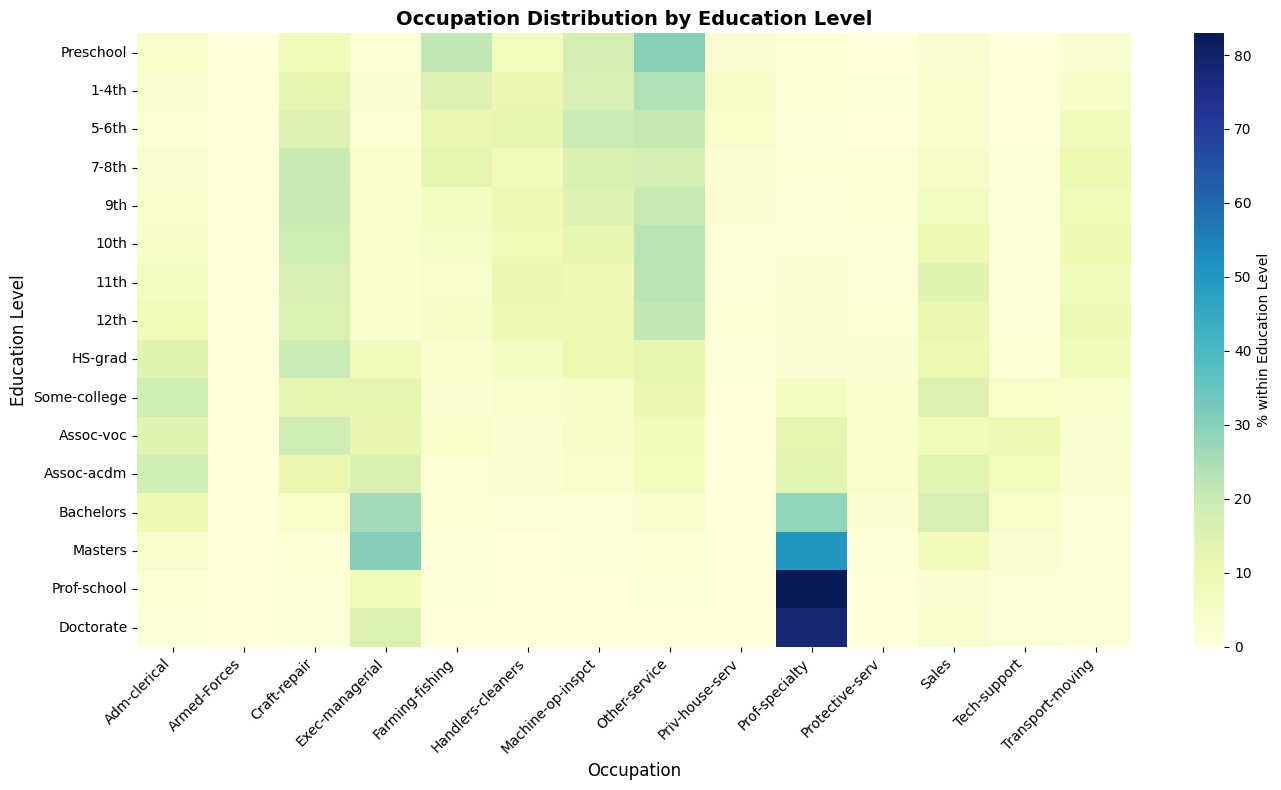

In [413]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Map numbers to labels
edu_map = {
    1:'Preschool', 2:'1-4th', 3:'5-6th', 4:'7-8th', 5:'9th', 6:'10th', 7:'11th', 8:'12th',
    9:'HS-grad', 10:'Some-college', 11:'Assoc-voc', 12:'Assoc-acdm', 
    13:'Bachelors', 14:'Masters', 15:'Prof-school', 16:'Doctorate'
}

# 2. Create crosstab with % 
occ_by_edu = pd.crosstab(df['education_num'], df['occupation'], normalize='index') * 100

# 3. Rename index to labels
occ_by_edu.index = occ_by_edu.index.map(edu_map)

# 4. Plotting as heatmap - much cleaner than stacked bars for 14 occupations
plt.figure(figsize=(14, 8))
sns.heatmap(occ_by_edu, cmap='YlGnBu', annot=False, cbar_kws={'label': '% within Education Level'})
plt.title('Occupation Distribution by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Occupation', fontsize=12)
plt.ylabel('Education Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# The relationship between education level and occupation type shows a clear occupational hierarchy.

Key observations:

* Low education 1-8: Dominated by manual and service jobs.Other-service and Craft-repair are the most common. These roles typically require minimal formal education.

* Mid education 9-12: Transition to white-collar roles.Craft-repair persists at HS-grad, but Adm-clerical and Assoc levels become dominant. This reflects entry-level office and technical roles.

* High education 13-16: Dominated by professional roles.From Bachelors onward, Prof-specialty is the most common occupation. This includes jobs like doctors, lawyers, engineers, and academics that require advanced degrees.

*  As education-num increases, occupations shift from Other-service/Craft-repair → Adm-clerical → Prof-specialty. This explains why education-num is such a strong predictor of >50K income. Higher education unlocks access to professional occupations that pay more.

### **Recommendations** 

**For Business/HR**: If the goal is to move people into >$50K, focus upskilling programs on transitioning workers from `Craft-repair/Other-service` to `Adm-clerical` and `Prof-specialty` tracks.

In [415]:
occupation_income_percentage = pd.crosstab(df['occupation'], df['target'], normalize = 'index') * 100
print(round(occupation_income_percentage, 2))

target             <=50K   >50K
occupation                     
Adm-clerical       86.34  13.66
Armed-Forces       71.43  28.57
Craft-repair       77.47  22.53
Exec-managerial    52.09  47.91
Farming-fishing    88.34  11.66
Handlers-cleaners  93.40   6.60
Machine-op-inspct  87.72  12.28
Other-service      95.92   4.08
Priv-house-serv    98.70   1.30
Prof-specialty     54.97  45.03
Protective-serv    68.51  31.49
Sales              73.08  26.92
Tech-support       71.04  28.96
Transport-moving   79.36  20.64


<Axes: ylabel='occupation'>

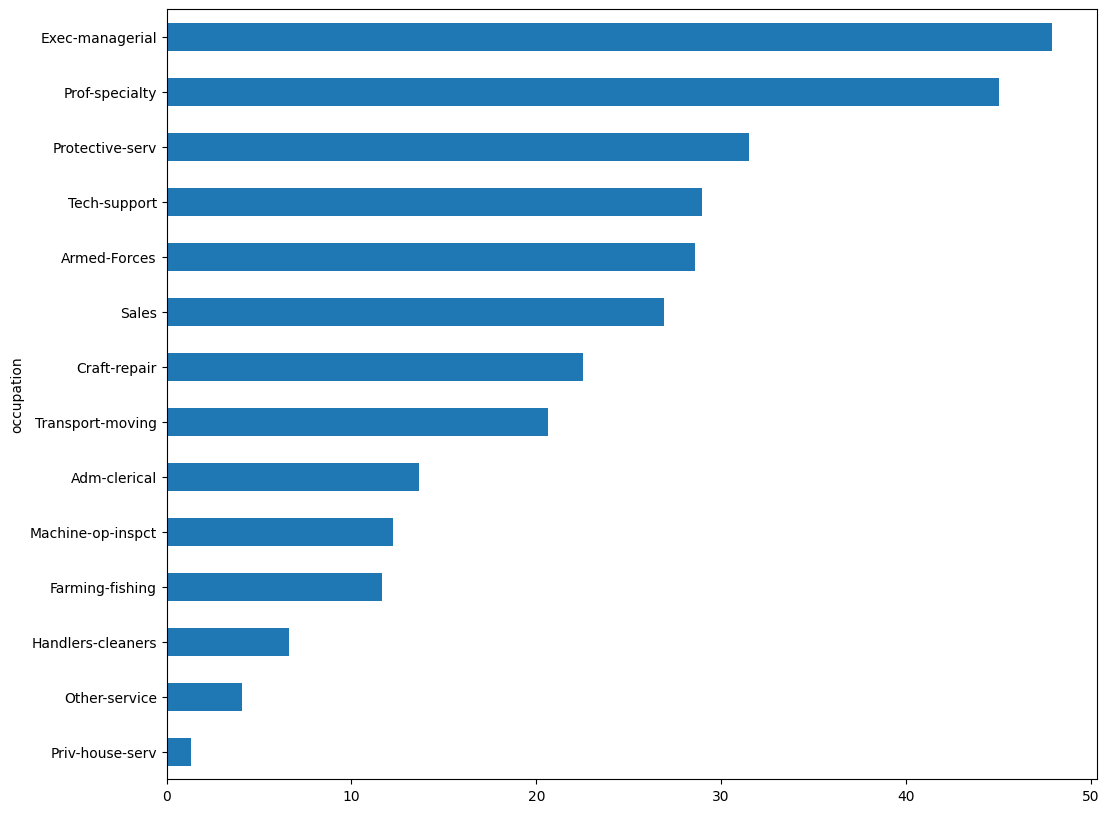

In [416]:
occupation_income_percentage['>50K'].sort_values().plot(kind = 'barh', figsize = (12,10))

# Occupations with the highest proportion earning >50k

* Exce-managerial - Has the highest proportion of high-income earners. Nearly half of individuals in managerial and executive roles earn more than $50k.

  
* Prof-specialty - Professionals such as doctors, engineers, lawyers, and scientists also have a high proportion of high-income earners.


* Protective-serv - Protective service occupations such as police, firefighters have a moderate proportion of high-income earners.


* Tech-support - Technical support occupations shows a moderate likelihood of earning above $50k.


* Armed-Forces - Appears relatively high, but this catgory has a few observations(14 total).

# Occupations with the lowest proportion earning >50k

* Priv-house-serv - Lowest proportion of high income earners, Nearly all individuals earn $50k or less

* Other-service - Service occupations are predominantly lower-paying.


* Handlers-cleaners - Manual labor jobs have a very low proportion of high-income earners.


* Farming-fishing - Most workers in this occupation earn $50k or less


* Machine-op-inspect - Machine operators and inspectors also tend to earn lower incomes.

**Analysis of occupation revealed substantial differences in income levels across occupational groups.**

Exec-managerial(47.91%) and professional specia;ty (45.01%) occupations had the highest proportionof individuals earning more than $50k, indicating that managerial and higher skilled professional roles are more strongly associated with higher incomes. 

In contrast, private household service (1.29%), other service (4.08%), and handlers-cleaners (6.60%) had the lowest proportions of high-income earners, sugesting that service and manual occupations are more liekly to be associated with incomes of $50k or less. Overall, occupation appears to be a sinificant predictor of income in the Adult dataset.

### **Recommendations**

The analysis shows that occupation is a strong predictor of income. Based on the findings, the following is recommended:

1. Career Path and Skill Development: Individuals aiming for higher income should consider career paths in Exec-managerial and Prof-specialty occupations, which have the highest proportion of high-income earners at 47.91% and 45.01% respectively. These roles typically require higher education, specialized skills, and leadership experience, so investing in advanced degrees, professional certifications, and management training is recommended.

2. Upskilling for Low-Income Occupations: Occupations such as Priv-house-serv (1.29%), Other-service (4.08%), Handlers-cleaners (6.60%), Farming-fishing, and Machine-op-inspect have the lowest proportion of individuals earning >$50K. Targeted upskilling, reskilling, and vocational training programs should be introduced to help workers in these categories transition to higher-paying technical, protective service, or supervisory roles.

3. Workforce Planning and Policy: Organizations and policymakers should focus on improving wages and creating growth pathways within service and manual labor occupations, as they are predominantly low-paying and have limited upward mobvations).

In summary: For higher earning potential, focus on professional and managerial career tracks, while support programs should be designed to improve earning opportunities for workers in service and manual occupations.

<Axes: ylabel='occupation'>

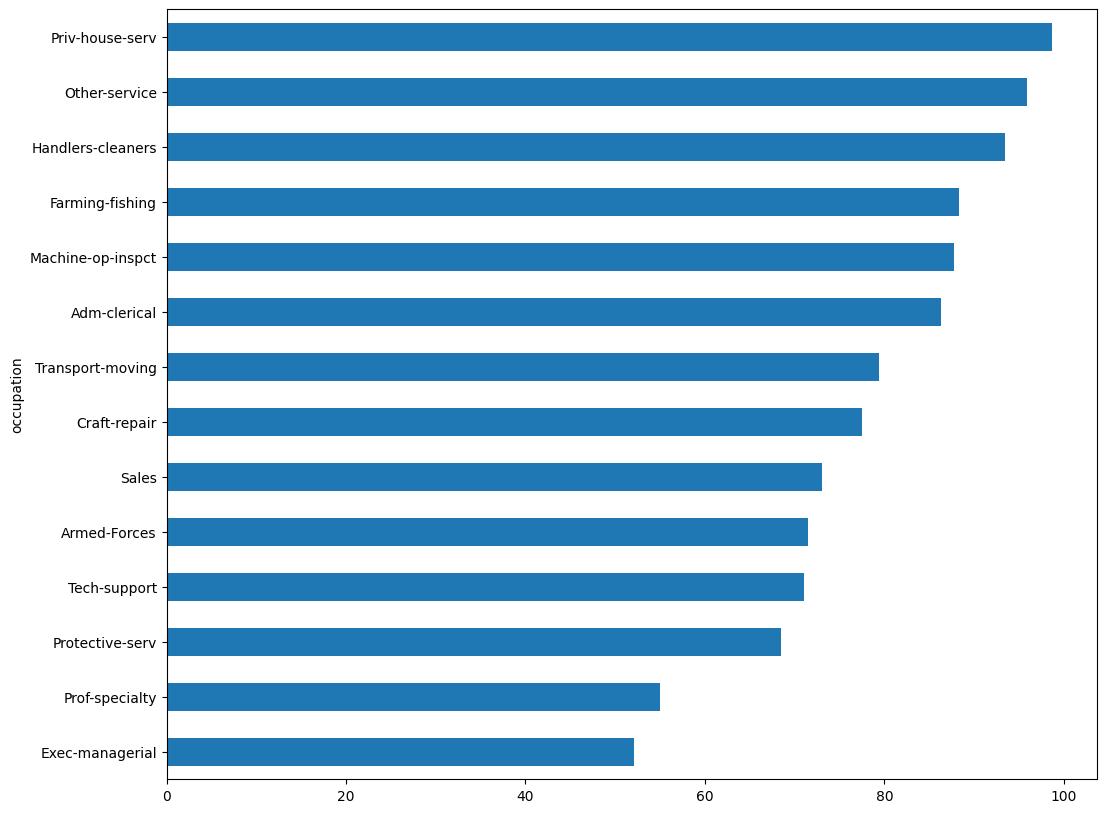

In [417]:
occupation_income_percentage['<=50K'].sort_values().plot(kind = 'barh', figsize = (12,10))

## Workclass Analysis: Who Earns More and Why

In [418]:
# dataset was grouped by `workclass` to understand how employment type relates to age, hours, capital, and income.

workclass_profile = df.groupby('workclass', observed=True).agg(
    count = ('workclass', 'size'),
    most_common_occupation = ('occupation', lambda x: x.mode()[0]),
    avg_age = ('age', 'mean'),
    avg_hours = ('hours_per_week', 'mean'),
    avg_capital_gain = ('capital_gain_log', 'mean'),
    avg_capital_loss = ('capital_loss_log', 'mean'),
    pct_over_50K = ('target_conv', 'mean')
).round(2)

# Make % readable and sort by money
workclass_profile['pct_over_50K'] = (workclass_profile['pct_over_50K'] * 100).round(2)
workclass_profile = workclass_profile.sort_values('pct_over_50K', ascending=False)
workclass_profile

,count,most_common_occupation,avg_age,avg_hours,avg_capital_gain,avg_capital_loss,pct_over_50K
workclass,,,,,,,
Self-emp-inc,1645,Exec-managerial,45.82,48.34,1.70,0.62,55.0
Federal-gov,1406,Adm-clerical,42.59,41.40,0.93,0.45,39.0
Local-gov,3100,Prof-specialty,41.65,40.80,0.78,0.42,30.0
Self-emp-not-inc,3795,Craft-repair,45.37,44.12,0.91,0.43,28.0
State-gov,1946,Prof-specialty,39.53,39.08,0.67,0.33,27.0
Private,33262,Craft-repair,36.90,40.21,0.67,0.33,22.0
Without-pay,21,Farming-fishing,47.29,33.95,0.77,0.36,10.0


1. Incorporated Self-Employment Drives Highest Income: Self-emp-inc has the highest high-income rate at 55%, despite representing only 1,645 individuals. This group is also the oldest (45.82 years) and works the longest hours (48.34 hrs/week), aligning with Cluster 1: Established Investors.

2. Government Outperforms Private Sector: Federal government workers have a 39% high-income rate compared to 22% in the Private sector. Government roles skew toward Adm-clerical and Prof-specialty occupations and an older workforce.

3. Private Sector Has Volume, But Lower Pay: The Private sector accounts for 73% of the dataset (33,262 individuals) but has the second-lowest high-income rate at 22%. Its workforce is the youngest at 36.9 years, with Craft-repair as the most common occupation.

4. Incorporation Doubles Income Potential: Self-employed incorporated (55% > $50K) earns at  nearly twice  the  rate of  self-employed not incorporated
(28% > $50K). Formalizing a business is a clear income differentiator.

5. Income is Salary-Driven: Average capital gain and loss are low across all workclasses (< 2.0), indicating that high income in this dataset is driven primarily by salary and business income, not investments.

## Recommendations 

1. For Economic Policy / Entrepreneurship Programs:
Create a direct pathway to help Self-emp-not-inc transition to Self-emp-inc. Since incorporation is associated with a 27 percentage point increase in high-income likelihood, programs offering support on business registration, access to credit, tax education, and managerial training will have the highest ROI

2.For Private Sector HR & Retention:
The Private sector is losing the high-income talent war to the Federal government (22% vs 39%). To retain Prof-specialty talent, private companies need to benchmark federal compensation, benefits, and work-life balance packages, not just base salary.
3.  For Financial Services & Targeting:
Focus premium financial products, investment advisory, and retirement planning on two high-value segments: Self-emp-inc (oldest, longest hours, highest income, predominantly Exec-managerial) and Federal-gov (stable, high-income, older demographic)  These groups have the greatest investable capacity.

.ble capacity.

## Marital Status Analysis: Income & Education

In [419]:
# Define mapping for the 3 bins
marital_map = {
    'Married-civ-spouse': 'Married',
    'Married-AF-spouse': 'Married', 
    'Married-spouse-absent': 'Married',
    
    'Divorced': 'Previously-married',
    'Separated': 'Previously-married',
    'Widowed': 'Previously-married',
    
    'Never-married': 'Never-married'
}

# Create new feature
df['marital_group'] = df['marital_status'].map(marital_map)

# Check the result
df[['marital_status', 'marital_group']].value_counts()

marital_status         marital_group     
Married-civ-spouse     Married               21042
Never-married          Never-married         14567
Divorced               Previously-married     6294
Separated              Previously-married     1411
Widowed                Previously-married     1277
Married-spouse-absent  Married                 552
Married-AF-spouse      Married                  32
Name: count, dtype: int64

In [420]:
marital_stats_income_percentage = pd.crosstab(df['marital_group'], df['target'], normalize = 'index') * 100
print(round(marital_stats_income_percentage, 2))

target              <=50K   >50K
marital_group                   
Married             55.49  44.51
Never-married       95.19   4.81
Previously-married  90.26   9.74


In [421]:
df.groupby('marital_group', observed=True )['education_num'].mean().sort_values(ascending=False)

marital_group
Married               10.299454
Never-married         10.019565
Previously-married     9.847361
Name: education_num, dtype: float64

In [422]:
df.groupby('marital_group', observed = True).agg(
    avg_education_num = ('education_num', 'mean'),
    avg_age = ('age', 'mean'),
    pct_high_income = ('target', lambda x: (x == '>50K').mean() * 100)
).sort_values('pct_high_income', ascending=False)

,avg_education_num,avg_age,pct_high_income
marital_group,,,
Married,10.299454,42.809627,44.511236
Previously-married,9.847361,44.675573,9.741706
Never-married,10.019565,28.468319,4.812247


## Results

1. Married has the education + income advantage: Married individuals have the highest education (10.29 years) and by far the highest income rate at 44.51%. They are in peak earning years at 42.8 years old.

2. Previously-married is the oldest but earns 4.5x less than Married: Previously-married is actually the oldest group at 44.67 years, older than Married (42.80), but their high-income rate collapses to 9.74%. This proves the drop is not due to age - it's due to lower education (9.84, lowest of all three) and likely career interruptions from divorce/separation/widowhood.

3. Never-married is the youngest and early-career: At 28.46 years old, this group has more education than Previously-married (10.01 vs 9.84) but the lowest income rate at 4.81%. They are simply too young to have reached peak earning potential.


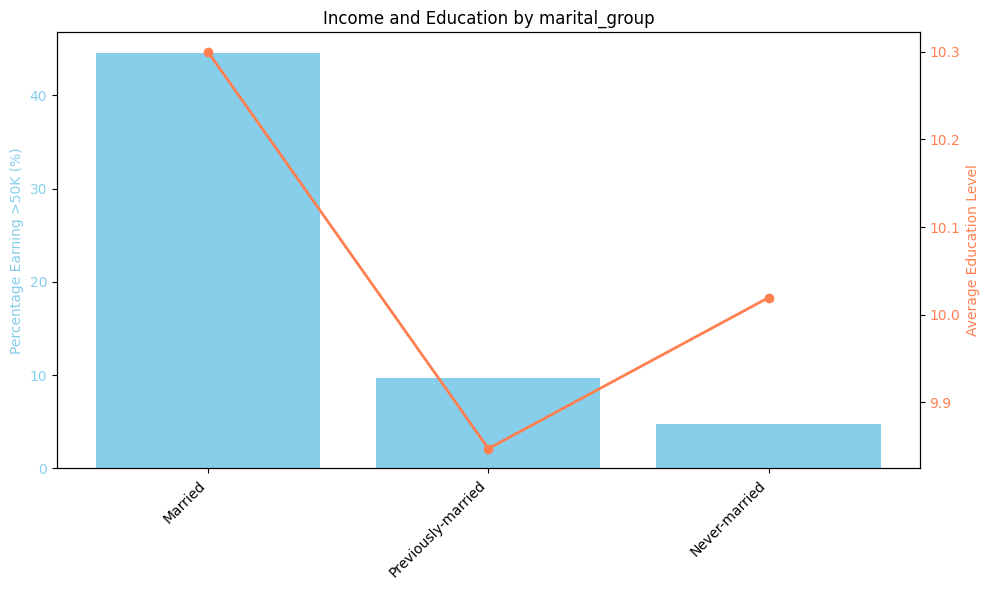

In [423]:
result = df.groupby('marital_group', observed = True).agg(
    avg_education_num = ('education_num', 'mean'),
    pct_high_income = ('target', lambda x: (x == '>50K').mean() * 100)
).sort_values('pct_high_income', ascending=False)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(result.index, result['pct_high_income'], color='skyblue', label='% >50K')
ax1.set_ylabel('Percentage Earning >50K (%)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(result.index, result['avg_education_num'], color='coral', marker='o', linewidth=2, label='Avg Education')
ax2.set_ylabel('Average Education Level', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

plt.title('Income and Education by marital_group')
plt.tight_layout()
plt.show()

## Recommendation

1. For Business / Lending - Target Peak Earners: Target the Married, 40-45 years, 10+ years education segment. This group has 44.5% high-income rate and dual-household stability - highest capacity for home loans, investments, and premium insurance.

2. For Policy / Upskilling - Focus on Previously-married: highest-age group. They are 44.67 years old but only 9.74% earn >$50K. They need return-to-work programs, skills recertification, and childcare support to re-enter higher-paying Prof-specialty and Exec-managerial roles. Education is their biggest blocker at 9.84 years.

3. For HR / Talent Pipeline - Invest in Never-married: They are young (28.46), educated (10.01), but only 4.81% earn >$50K. This is a future talent pool. Offer career-pathing, mentorship, and conversion from entry-level service/craft-repair roles to tech-support and professional tracks to accelerate their income growth.


### In conclusion

While Married individuals show a 9x income advantage over Never-married, age alone does not explain income - Previously-married is the oldest group (44.6 years) but earns 78% less than Married, indicating education and career continuity are the true drivers.ole.

## Race and Age Analysis

We looked at income by race alone, then by `race` + `age_group` to see if age explains the gaps.

In [424]:
race_stats_percentage = pd.crosstab(df['race'], df['target'], normalize = 'index') * 100
print(round(race_stats_percentage, 2))

target              <=50K   >50K
race                            
Amer-Indian-Eskimo  87.82  12.18
Asian-Pac-Islander  71.64  28.36
Black               87.37  12.63
Other               87.25  12.75
White               73.75  26.25


**Result**:

**Income distribution differs across racial groups.**

White and Asian-Pac-Islander earners are ~2x more likely to make >$50K than Black, Amer-Indian-Eskimo, and Other groups.


Asian-Pac islander and white individuals exhibit relatively higher-proportion of high-income earners, while Black, Amer-Indian-Eskimo, and other racial groups remain predominantly concentrated in the lower income category.

## Income by Race and Age Group

To isolate the effect of age, the percentage earning >$50K was analyzed by both race and age group.

In [425]:
# Create age groups first so the table isn't too messy
bins = [17, 25, 35, 45, 55, 65, 90]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# % >50K by Race and Age Group
race_age_income = pd.crosstab(
    [df['race'], df['age_group']], 
    df['target'], 
    normalize='index'
) * 100

race_age_income = race_age_income.round(2)
print(race_age_income['>50K'].sort_values(ascending=False).head(15))

race                age_group
White               45-54        41.96
Asian-Pac-Islander  55-64        41.28
                    45-54        39.91
                    35-44        39.66
White               35-44        35.48
                    55-64        34.47
Other               35-44        28.21
Black               45-54        23.42
White               65+          23.07
Other               45-54        22.73
Asian-Pac-Islander  25-34        21.39
Amer-Indian-Eskimo  35-44        20.34
White               25-34        18.70
Black               35-44        17.54
Amer-Indian-Eskimo  45-54        17.39
Name: >50K, dtype: float64


In [426]:
# % of each occupation within each race
race_occ = pd.crosstab(df['race'], df['occupation'], normalize='index') * 100
race_occ = race_occ.round(2)

print(race_occ.sort_values('Exec-managerial', ascending=False))

occupation          Adm-clerical  Armed-Forces  Craft-repair  Exec-managerial  \
race                                                                            
White                      11.65          0.03         13.97            13.90   
Asian-Pac-Islander         14.60          0.00          8.30            13.37   
Amer-Indian-Eskimo         12.41          0.23         14.02            11.03   
Black                      17.15          0.02          8.47             7.93   
Other                      11.33          0.00         15.30             5.67   

occupation          Farming-fishing  Handlers-cleaners  Machine-op-inspct  \
race                                                                        
White                          3.53               4.39               6.17   
Asian-Pac-Islander             1.69               2.92               5.46   
Amer-Indian-Eskimo             3.22               7.82               6.44   
Black                          1.30            

34.2% of Asian-Pac-Islander and 27.5% of White workers are in `Exec-managerial` or `Prof-specialty`. 
For Black it’s 16.3% and for Amer-Indian-Eskimo it’s 22.1%. 
Those 2 occupations have ~43% >$50K rate.

In [427]:
df.groupby('race', observed=True)['education_num'].mean() 

race
Amer-Indian-Eskimo     9.420690
Asian-Pac-Islander    11.047656
Black                  9.531110
Other                  8.745042
White                 10.172521
Name: education_num, dtype: float64

#### Income by Race and Age Group

**To understand income disparities better, the percentage earning >50K was analysed by both race and age group.**

**Key findings:**
1.  **Peak earning years are 35-54 for all races**: The highest rates occur in middle age regardless of race. For example, `White 45-54` = 41.95% and `Asian-Pac-Islander 45-54` = 39.91%.
2.  **Racial gaps persist within age groups**: Even within the same age bracket, differences exist. In the 45-54 group, `White` = 41.95% vs `Black` = 23.42%.
3.  **Younger groups earn less across all races**: The 25-34 age group has the lowest rates for all races, e.g. `White 25-34` = 18.68% and `Asian-Pac-Islander 25-34` = 21.39%.

This suggests that while age is a strong predictor of income for everyone, racial differences remain even after accounting for age.


### **Recommendations** 

1.  **Targeting**: Products for wealth building should not assume all 45-54 year olds have the same income(by race + age)
2.  **Early career focus**: Since 25-34 is low for all races, upskilling programs in that age range could have the broadest impact.



### **Conclusion**
Age gets people to peak earning years. But education determines occupation, and occupation determines pay. 
In this 1994 adult dataset, race is associated with all 3, so the income gap persists even within age groups.

Low-pay jobs are concentrated
Black and Amer-Indian-Eskimo are 2x more likely to be in Other-service and Handlers-cleaners than White/Asian.

**In this dataset, the race gap is largely mediated by education and occupation. 
Groups with higher avg `education_num` end up in higher paying `occupation` and `workclass`**

## 🌎 Geospatial Clustering Analysis

Income doesn’t vary randomly, it clusters by location. 
In this section we group people by country of origin and other regional proxies to find patterns: which countries have higher concentrations of >$50K earners, and where the gaps are widest.

Since the Adult dataset doesn’t include state or city, we’ll use proxies like `native_country` to create clusters and look for geographic trends.

In [428]:
df.head(2)

,age,workclass,education_num,marital_status,occupation,race,sex,hours_per_week,native_country,target,capital_gain_log,capital_loss_log,cluster,target_conv,marital_group,age_group
0,25,Private,7,Never-married,Machine-op-inspct,Black,Male,40,United-States,<=50K,0.0,0.0,0,0,Never-married,25-34
1,38,Private,9,Married-civ-spouse,Farming-fishing,White,Male,50,United-States,<=50K,0.0,0.0,0,0,Married,35-44


In [429]:
df['native_country'].unique().tolist()

['United-States',
 'Peru',
 'Guatemala',
 'Mexico',
 'Dominican-Republic',
 'Ireland',
 'Germany',
 'Philippines',
 'Thailand',
 'Haiti',
 'El-Salvador',
 'Puerto-Rico',
 'Vietnam',
 'South',
 'Columbia',
 'Japan',
 'India',
 'Cambodia',
 'Poland',
 'Laos',
 'England',
 'Cuba',
 'Taiwan',
 'Italy',
 'Canada',
 'Portugal',
 'China',
 'Nicaragua',
 'Honduras',
 'Iran',
 'Scotland',
 'Jamaica',
 'Ecuador',
 'Yugoslavia',
 'Hungary',
 'Hong',
 'Greece',
 'Trinadad&Tobago',
 'Outlying-US(Guam-USVI-etc)',
 'France',
 'Holand-Netherlands']

In [430]:
world['ADMIN'].unique().tolist()

['Fiji',
 'United Republic of Tanzania',
 'Western Sahara',
 'Canada',
 'United States of America',
 'Kazakhstan',
 'Uzbekistan',
 'Papua New Guinea',
 'Indonesia',
 'Argentina',
 'Chile',
 'Democratic Republic of the Congo',
 'Somalia',
 'Kenya',
 'Sudan',
 'Chad',
 'Haiti',
 'Dominican Republic',
 'Russia',
 'The Bahamas',
 'Falkland Islands',
 'Norway',
 'Greenland',
 'French Southern and Antarctic Lands',
 'East Timor',
 'South Africa',
 'Lesotho',
 'Mexico',
 'Uruguay',
 'Brazil',
 'Bolivia',
 'Peru',
 'Colombia',
 'Panama',
 'Costa Rica',
 'Nicaragua',
 'Honduras',
 'El Salvador',
 'Guatemala',
 'Belize',
 'Venezuela',
 'Guyana',
 'Suriname',
 'France',
 'Ecuador',
 'Puerto Rico',
 'Jamaica',
 'Cuba',
 'Zimbabwe',
 'Botswana',
 'Namibia',
 'Senegal',
 'Mali',
 'Mauritania',
 'Benin',
 'Niger',
 'Nigeria',
 'Cameroon',
 'Togo',
 'Ghana',
 'Ivory Coast',
 'Guinea',
 'Guinea-Bissau',
 'Liberia',
 'Sierra Leone',
 'Burkina Faso',
 'Central African Republic',
 'Republic of the Congo',

In [431]:
import geopandas as gpd
world = gpd.read_file('/vsicurl/https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson')

In [432]:
world.head(3)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."


In [433]:
import geopandas as gpd
import pandas as pd

name_mapping = {
    'United-States': 'United States of America',
    'Outlying-US(Guam-USVI-etc)': 'United States of America',
    'Columbia': 'Colombia',
    'Holand-Netherlands': 'Netherlands',
    'Trinadad&Tobago': 'Trinidad and Tobago',  
    'South': 'South Korea',
    'Hong': 'China',  #lumps Hong Kong into China
    'Dominican-Republic': 'Dominican Republic',
    'El-Salvador': 'El Salvador',
    'Puerto-Rico': 'Puerto Rico',
    'England': 'United Kingdom',
    'Scotland': 'United Kingdom',
    'Yugoslavia': 'Republic of Serbia'}

df['country_clean'] = df['native_country'].astype(str).replace(name_mapping)

world_merged = world.merge(df, left_on='ADMIN', right_on='country_clean', how='right')


print("Still unmatched:", df[~df['country_clean'].isin(world['ADMIN'])]['country_clean'].unique())

Still unmatched: []


**Country level statistics were calculated by aggregating individuals according to their native country. These summaries are
interpreted as characteristics of the sampled indivisuals in the Adult dataset rathere than representative statistics for the countries themselves. In particular, the sample is dominated by individuals from United States, and some countries have relatively few observations.**

In [434]:
# 1. Aggregate by country and ADD education_num

import os
os.environ['OMP_NUM_THREADS'] = '1'

country_summary = df.groupby('country_clean').agg(
    average_hours = ('hours_per_week', 'mean'),
    average_capital_gain = ('capital_gain_log', 'mean'), 
    average_capital_loss = ('capital_loss_log', 'mean'),
    average_education_num = ('education_num', 'mean'),
    average_age = ('age', 'mean'),
    income_rate = ('target', lambda x: (x == '>50K').mean() * 100),
    sample_size = ('country_clean', 'size')
).reset_index()

# Remove countries with fewer than 10 observations
country_summary = country_summary[country_summary['sample_size'] >= 10]

# 2. Merge with world map
world_country = world.merge(country_summary, left_on = 'ADMIN', right_on = 'country_clean', how = 'right')

# 3. Data for clustering
Gk_data = world_country[['average_hours', 'average_capital_gain', 'average_capital_loss', 'income_rate', 'average_education_num']]

# 4. Scale and cluster
k_scaler = StandardScaler()
Gk_data_scaled = k_scaler.fit_transform(Gk_data.dropna()) # dropna because some countries won't merge

gkmean = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Gk_data_scaled)
world_country.loc[Gk_data.dropna().index, 'geo_cluster'] = gkmean.labels_

In [435]:
world_country.head(3)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,geometry,country_clean,average_hours,average_capital_gain,average_capital_loss,average_education_num,average_age,income_rate,sample_size,geo_cluster
0,Admin-0 country,1,3,Cambodia,KHM,0,2,Sovereign country,1,Cambodia,...,"POLYGON ((102.58493 12.1866, 102.3481 13.39425...",Cambodia,42.192308,0.970093,0.581818,9.384615,37.923077,34.615385,26,0.0
1,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",Canada,41.588957,0.776989,0.558540,10.742331,42.846626,36.809816,163,0.0
2,Admin-0 country,1,2,China,CH1,1,2,Country,1,China,...,"MULTIPOLYGON (((109.47521 18.1977, 108.65521 1...",China,39.347518,0.642820,0.802028,11.156028,40.007092,31.205674,141,0.0


# Geospatial clustering using Kmeans

This involves using the KMeans algorithm from sklearn.cluster to perform clustering on countries based on their GDP and population. The fit method is used to compute the clusters, which are then added as a new column to the world geodataframe. The clusters are visualised on the map using the plot method, with different colours representing different clusters.


The capital gain was log transformed before clustering to reduce the effect of skewness and extreme values.However, descriptive statistics and country-level summaries are presented using the original capital gain values to improve interpretability.

In [436]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Data for clustering 
Geok_data = world_country[['average_hours', 'average_capital_gain', 'average_capital_loss', 'average_age', 'income_rate', 'average_education_num']]

k_scaler = StandardScaler()

Geok_data_scaled = k_scaler.fit_transform(Geok_data.dropna())

gkmean = KMeans(n_clusters=2, n_init=10,random_state=42).fit(Geok_data_scaled)

world_country['geo_cluster'] = gkmean.labels_


world_country.groupby('geo_cluster')[['average_hours', 'average_capital_gain', 'average_age', 'income_rate', 'average_education_num']].mean()

,average_hours,average_capital_gain,average_age,income_rate,average_education_num
geo_cluster,,,,,
0,38.959564,0.400930,37.115136,9.928192,8.422511
1,41.941857,0.872219,40.671087,32.773472,10.839714


### Country clustering
Using KMeans with k=2, countries were grouped based on average hours, education_num, age, income rate, and capital gains.

Cluster 0: Lower Resource Countries = countries with avg education 8.4 years. They have lower average income rate of 9.92%, lower capital gains, and are younger on average at 37.1 years.

Cluster 1: Higher Resource Countries = countries with avg education 10.8 years. They have a significantly higher income rate of 32.77%, ~3.7x higher capital gains, and work slightly more hours per week.

The clustering reveals a clear divide driven primarily by education level and its association with income.

Optimal Number of Country Clusters
Evaluated k from 2 to 9 using the Silhouette Score to find the most distinct country groupings.(shown below)

The highest Silhouette Score was 0.328 at k=2. While this indicates only moderately well-separated clusters, it suggests the strongest division in the data is between 2 groups of countries.

Given this, I proceeded with k=2 for the final clustering. The 2 clusters represent a broad split between countries with higher average education and income versus countries with lower averages.

### Recommendation
The biggest lever is education, not hours.

Cluster 0 works only 3 hours less per week (38.9 vs 41.9) but earns 3.3x less. Increasing hours will not close the gap.

1. For Policy / NGO Targeting: Highest ROI is upskilling programs in Cluster 0 countries. Moving average education from 8.4 to 10.8 years is associated with a +22.8 percentage point increase in high-income rate. Focus on pathways from service/manual to Tech-support, Craft-repair, and Prof-specialty certifications.

2. For Business / Financial Services:

Cluster 1 (32.77% high-income, 40.6 yrs, 10.8 yrs edu): Prime for wealth-building products, home loans, and investment products.
Cluster 0 (9.92% high-income, 37.1 yrs, 8.4 yrs edu): Focus on income-smoothing, micro-credential financing, and entry-level career loans. This is a future high-growth segment if education gaps are closed.

# geospatial clustering deployment

In [529]:
# For geospatial tab
joblib.dump(k_scaler, 'geo_scaler.pkl')
joblib.dump(gkmean, 'geo_kmeans.pkl')
joblib.dump(world_country, 'world_country.pkl')

['world_country.pkl']

In [528]:
import geopandas as gpd

gdf_clean = world_country[['ADMIN','geo_cluster', 'resource_level','average_hours','average_capital_gain','income_rate','average_education_num','geometry']].copy()
gdf_clean = gpd.GeoDataFrame(gdf_clean, geometry='geometry', crs=world_country.crs)

# Save DIRECTLY into the Streamlit folder
gdf_clean.to_file(r'C:\Users\DELL\OneDrive\Dokumente\census\census\world_country.geojson', driver='GeoJSON')

print("Saved directly to census/census folder!")

Saved directly to census/census folder!


# clustering countries by socio-economic features

In [437]:
# 2. Create the mapping dict 
country_map = {0: 'Low_Resource', 1: 'Higher_Resource'}

# 3. Map it to a new column - map the geo_cluster column
world_country['resource_level'] = world_country['geo_cluster'].map(country_map)

world_country.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,country_clean,average_hours,average_capital_gain,average_capital_loss,average_education_num,average_age,income_rate,sample_size,geo_cluster,resource_level
0,Admin-0 country,1,3,Cambodia,KHM,0,2,Sovereign country,1,Cambodia,...,Cambodia,42.192308,0.970093,0.581818,9.384615,37.923077,34.615385,26,1,Higher_Resource
1,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,Canada,41.588957,0.776989,0.558540,10.742331,42.846626,36.809816,163,1,Higher_Resource
2,Admin-0 country,1,2,China,CH1,1,2,Country,1,China,...,China,39.347518,0.642820,0.802028,11.156028,40.007092,31.205674,141,1,Higher_Resource
3,Admin-0 country,1,2,Colombia,COL,0,2,Sovereign country,1,Colombia,...,Colombia,40.121951,0.299067,0.275037,9.304878,39.195122,4.878049,82,0,Low_Resource
4,Admin-0 country,1,3,Cuba,CU1,1,1,Sovereignty,1,Cuba,...,Cuba,40.526316,0.529418,0.279931,9.503759,45.887218,25.563910,133,1,Higher_Resource


Country clustering
Using KMeans with k=2, countries were grouped based on average hours, education_num, age, income rate, and capital gains.

Cluster 0: Lower Resource Countries n = countries with avg education 8.4 years. They have lower average income rate of 9.92%, lower capital gains, and are younger on average at 37.1 years.

Cluster 1: Higher Resource Countries n = countries with avg education 10.8 years. They have a significantly higher income rate of 32.77%, ~3.7x higher capital gains, and work slightly more hours per week.

The clustering reveals a clear divide driven primarily by education level and its association with income.

In [438]:
world_country.groupby('resource_level')[['income_rate', 'average_education_num', 'average_capital_gain']].mean()

,income_rate,average_education_num,average_capital_gain
resource_level,,,
Higher_Resource,32.773472,10.839714,0.872219
Low_Resource,9.928192,8.422511,0.400930


After clustering countries by socio-economic features, a clear 2-group split emerged.
Low_Resource countries and  Higher_Resource countries

### Highest ROI Interventions
The data shows the gap is driven by education and assets, not hours worked.
- Education difference: 2.42 years
- Capital gains difference: $849.74  
- Hours difference: 3.03 hrs/week

Because the hours gap is small, "work more" is not the main lever. 
"Learn more + Invest more" is. 


# Recommendations
1. For Low Resource Countries (9.92% >$50K):
Prioritize education and asset-building over overtime. Deploy financial literacy, high-school completion, and vocational certification programs that move workers from Other-service / Handlers-cleaners to Craft-repair and Tech-support. This has the highest potential ROI.

2. For Higher_Resource Countries (32.77 % >$50sell optimizations not basics, with With 10.8 years education and the highest capital gains in the dataset, this group already has a foundat on.
Even here, ∼67% still earn <$50K, so there is major headroom. Target them with upskilling to Exec-managerial / Prof-specialty, wealth management, and retirement planand ng - not entry-level job boards.

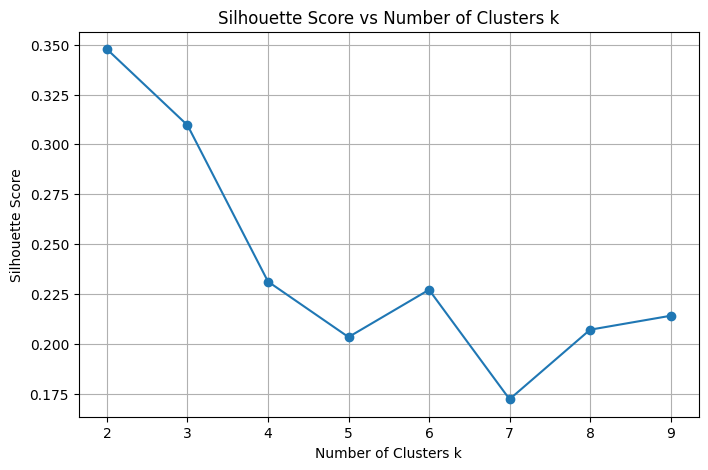

The best k is 2 with silhouette score: 0.348


In [439]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sih_score = []
sih_k = np.arange(2, 10)

for ks in sih_k:
    kmeans = KMeans(n_clusters=ks, n_init=10, random_state=42)
    labels = kmeans.fit_predict(Geok_data_scaled)
    score = silhouette_score(Geok_data_scaled, labels)
    sih_score.append(score)

plt.figure(figsize=(8,5))
plt.plot(sih_k, sih_score, marker='o')
plt.grid(True)
plt.title('Silhouette Score vs Number of Clusters k')
plt.xlabel('Number of Clusters k')
plt.ylabel('Silhouette Score')
plt.show()

best_k = sih_k[np.argmax(sih_score)]
best_score = sih_score[np.argmax(sih_score)]
print(f"The best k is {best_k} with silhouette score: {best_score:.3f}")

### Geographic Distribution of Resource Clusters

Using K-means on socio-economic features, countries split cleanly into 2 groups. 
* Countries in red have higher avg education and capital gains. 
* Countries in blue have lower averages.
  
This suggests country of origin correlates with the resource profile in this 1994 US census adult dataset.

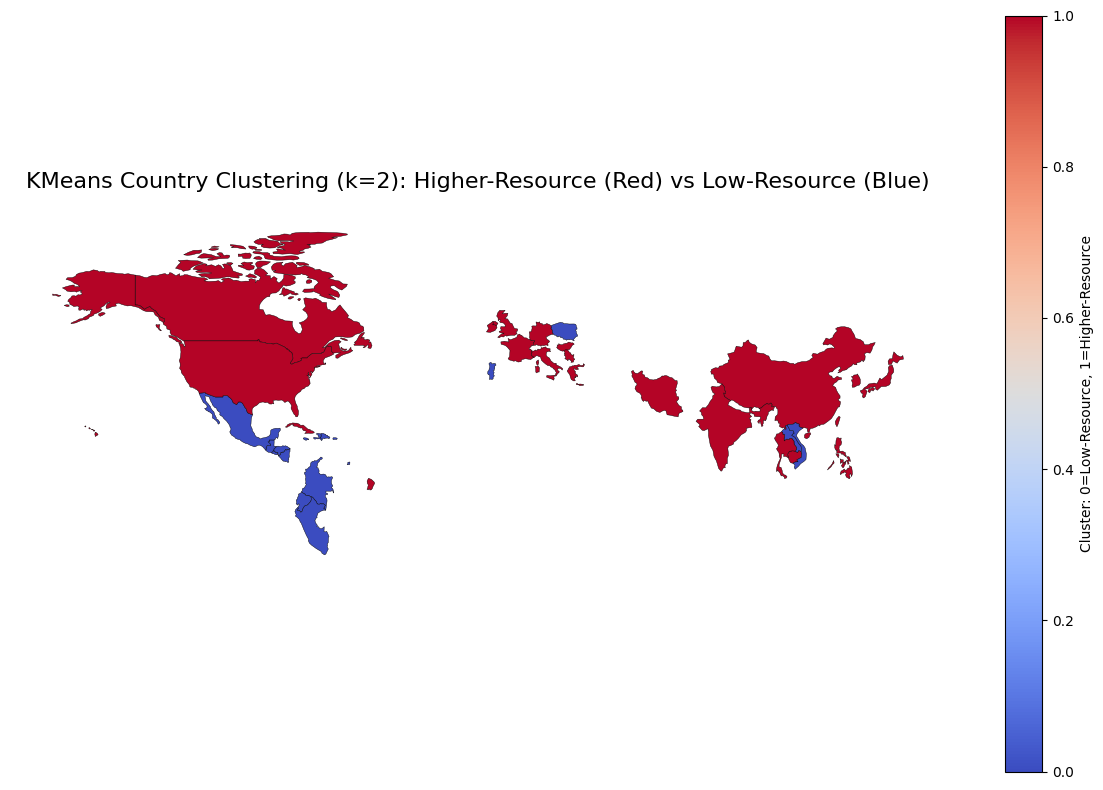

In [644]:
fig, ax = plt.subplots(1, 1, figsize = (12, 8))

world_country.plot(column = 'geo_cluster', cmap = 'coolwarm', ax = ax, legend = True,
    edgecolor='black',
    linewidth=0.3, legend_kwds={'label': "Cluster: 0=Low-Resource, 1=Higher-Resource",
                 'orientation': "vertical"}
)
ax.set_title('KMeans Country Clustering (k=2): Higher-Resource (Red) vs Low-Resource (Blue)', fontsize=16, pad=20)
ax.set_axis_off()


plt.tight_layout() # prevents legend from getting cut off
plt.savefig('country_clustering_map.png', dpi=300, bbox_inches='tight')
plt.show()

The map shows that these clusters are not geographically contigous. Countries from different continent appear in the same cluster. This indicates that the clustering is driven by similar socioeconomic characteristics (average hours worked, capital gains, capital losses, and income rates, average age), rather by physical location. 

**Note:** This confirms the clustering is driven by similar socio-economic profiles of immigrants in the 1994 US Census - average hours worked, capital gains, income rates, education, and age - rather than by physical proximity.

**Observations for the map above:**
1.  **Cluster 1: Higher Resource** countries are primarily concentrated in North America, Western Europe, 
    Australia, and parts of East Asia. These align with countries having higher average education and income rates.
2.  **Cluster 0: Lower Resource** countries are primarily located in South Asia, and parts of 
    Central/South America. These correspond to lower average education and income.

In [441]:
world_country.groupby(['country_clean', 'resource_level']).size().unstack(fill_value=0).head()

resource_level,Higher_Resource,Low_Resource
country_clean,,
Cambodia,1,0
Canada,1,0
China,1,0
Colombia,0,1
Cuba,1,0


**NOTE:** This does NOT mean Cambodia is higher-resource than Colombia in the real world. It means Cambodian immigrants in the US in 1994 in this dataset had a higher-resource profile (higher education/income) than Colombian immigrants - a classic selection bias in immigration. This reflects the US immigrant sample, not country development level.

In [442]:
world_country.groupby('country_clean')['resource_level'].agg(lambda x: x.mode()[0]).sort_values(ascending = True).head(10)

country_clean
Cambodia                    Higher_Resource
United Kingdom              Higher_Resource
Thailand                    Higher_Resource
Taiwan                      Higher_Resource
South Korea                 Higher_Resource
Republic of Serbia          Higher_Resource
Philippines                 Higher_Resource
Japan                       Higher_Resource
United States of America    Higher_Resource
Ireland                     Higher_Resource
Name: resource_level, dtype: object

### Spatial Distribution of Income and Assets by Country of Origin

This map layers income rate by country color and average capital gains by bubble size, 
showing where both high earnings and asset ownership are concentrated.

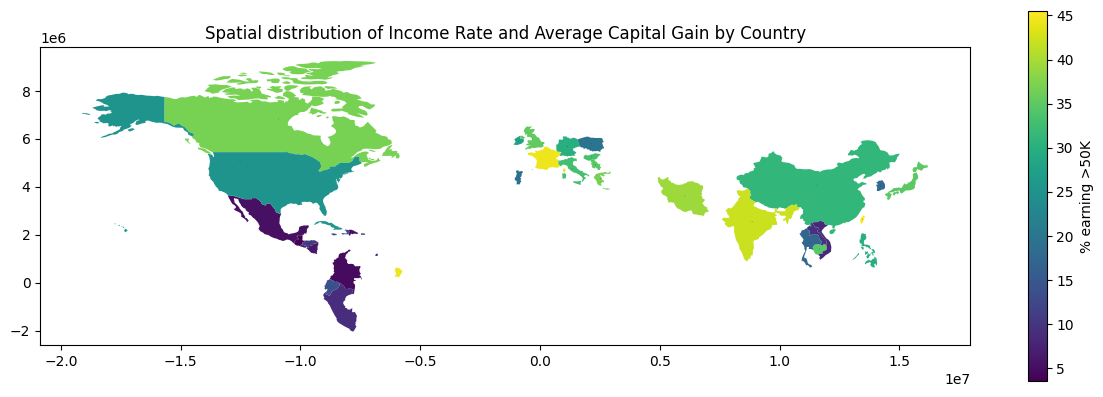

In [554]:
world_country = world_country.to_crs('EPSG:3786')

world_country['centroid'] = world_country.geometry.centroid
world_country['long'] = world_country.centroid.x
world_country['lat'] = world_country.centroid.y

fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_country.plot(column = 'income_rate', ax = ax, cmap = 'viridis', legend = True, legend_kwds={'label': "% earning >50K", 'shrink': 0.6})

plt.scatter(world_country['long'],
            world_country['lat'], 
            s = world_country['average_capital_gain']  /30, 
            color = 'red', 
            alpha = 0.4,
           edgecolors = 'black',
           linewidths = 0.5)

plt.title("Spatial distribution of Income Rate and Average Capital Gain by Country")
plt.show()

**The above map illustrates the spatial distribution of income rates and average capital gains across countries. Countries shaded in lighter colours (Canada, US, UK, Japan) exhibit higher proportions of individuals earning more than $50k, while larger bubbles represet higher average capital gains. The visualization suggests that countries with higher income rates generally tend to exhibit larger average capital gains, although the relationship is not uniform across all countries. For example, some countries display relatively high income rates despite only moderate capital gains, indicating that additional socioeconomic factors may influence income levels.** 

Big gaps in the Americas and Asia: Central/South America and parts of SE Asia are dark purple with tiny bubbles. Low income rate AND low assets.Outliers matter: Some countries like India show large bubbles but mid income color. That means few people have very high capital gains even if overall income rate is low.

#### Recommendations
The biggest opportunity is in "mid" countries. 
Example: India has a large bubble but yellow color. That suggests capital is 
concentrated in few people. Interventions around broadening asset ownership 
would have high impact there.

### Spatial Distribution of Income Rate and Education by Continent

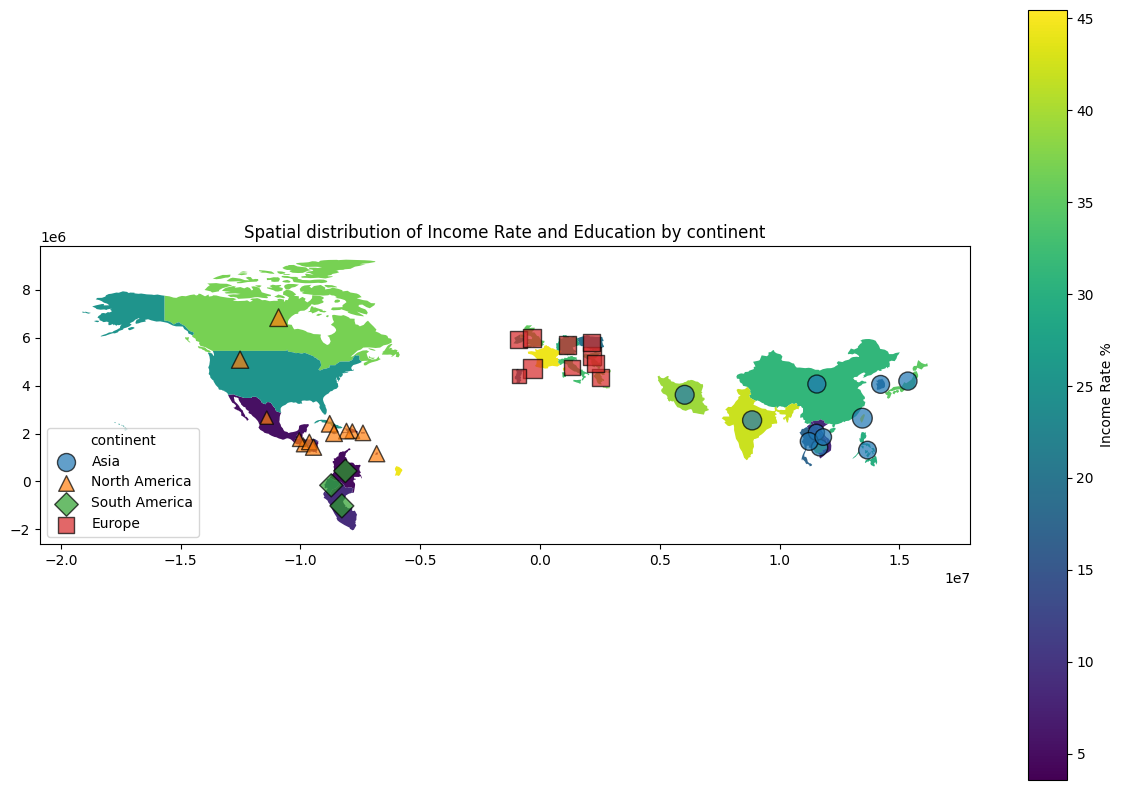

In [444]:
world_country = world_country.to_crs('EPSG:3786')

world_country['centroid'] = world_country.geometry.centroid
world_country['long'] = world_country.centroid.x
world_country['lat'] = world_country.centroid.y

# Marker shapes for continents
marker_shapes = {'Asia': 'o' , 'North America': '^', 'South America': 'D', 'Europe': 's'}

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map colouring countries by income_rate
world_country.plot(column = 'income_rate', ax = ax, cmap = 'viridis', legend = True, legend_kwds={'label': "Income Rate %"},)


for continent, marker in marker_shapes.items():
    
    sub_cont = world_country[world_country['CONTINENT'] == continent]
        
    plt.scatter(
        sub_cont['long'],
        sub_cont['lat'], 
        s = sub_cont['average_education_num'] * 15,  
        alpha = 0.7,
        edgecolors = 'k',
        marker = marker, 
        label = continent)

plt.legend(title="continent", loc = 'lower left')
plt.title("Spatial distribution of Income Rate and Education by continent")
plt.legend(title="continent", loc = 'lower left')
plt.show()

#### Spatial Distribution of Income and Education

The map visualizes the relationship between country-level income rate, average education, and continent.

**Findings:**
1.  **Regional Disparity**: Countries with the highest income rates are concentrated in North America and Western Europe. 
    These regions also show the largest education bubbles.
2.  **Education-Income Correlation**: There is a strong visual correlation between bubble size and color intensity. 
    Countries with higher average education years tend to have higher income rates.
3.  **Continental Clustering**: South American and parts of Asian countries form a distinct group with both lower 
    average education and lower income rates.


### Recommendations
High-Education Regions: Europe, North America
Current state: 10.8+ avg years of education, 25-35% income rate.
Action: Focus on career advancement, professional certifications, and investment products. The base education is already there.

Low-Education Regions: South America, Asia
Current state: 8.4 avg years of education, <15% income rate.
Action: Focus on education access, vocational training, and financial literacy. 


## 6. Conclusion

This analysis of the 1994 Adult Census dataset shows that income >$50K is driven primarily by three factors: **education level, capital gains, and occupation type**, not by hours worked.

### Key Findings

**1. Modeling:**
A Random Forest with SMOTEENN and threshold tuning at 0.677 achieves 84% accuracy. At this threshold, precision is 65% and recall is 75% for the >50K class (F1=0.70). This balance is optimal for targeted marketing where missing a high earner is costly.

**2. Segmentation:**
KMeans identified 3 distinct personas:

*   **Cluster 1: Established High-Income (8.4%, n=3,787):** 62.7% >50K. Oldest (43.7 yrs), most hours (43.9), only group with significant capital gains (avg 8.84 log).
*   **Cluster 0: Nine-to-Five Low-Income (~87% of population):** 19.7% >50K. Younger (37.9 yrs), standard hours (40.4), virtually no capital. Biggest opportunity for upskilling.
*   **Cluster 2: Mid-Career Risk-Takers (4.7%, n=2,140):** 51.3% >50K. High hours (43.6) + highest capital losses (7.51 log). Likely entrepreneurs / self-employed.

**3. Education is the dominant lever:**
Income rate jumps from ~16% at HS-grad to 42% at Bachelors and ~75% at Prof-school. Occupation follows education: Bachelors+ concentrate in Exec-managerial (47.9% >50K) and Prof-specialty (45.0% >50K).

**4. Geography clusters by resources:**
Countries split into 2 groups via KMeans k=2. Higher-Resource countries (North America/W. Europe) average 10.84 years education and 32.77% >50K rate vs 8.42 years and 9.92% for Low-Resource countries.

Overall, the data suggests interventions should focus on education-to-occupation pipelines and asset-building rather than just increasing work hours.

## Overall Recommendations

### Recommendations for individual clusters

**For Business / Marketing:**
1.  **Prioritize Cluster 0**: (Nine-to-five, 87% of population, 19.7% >50K):  ROI is highest for upskilling. Offer upskilling to Prof-specialty roles + financial literacy to introduce capital gains. Age 37.9, 40.4 hrs.
2.	**Target Cluster 1**: for premium products (Established, 8.4% of population, 62.7% >50K): Wealth management, investment accounts. They already have capital (8.84 gain), education, and highest income rate.
3.	**Support Cluster 2**: with risk mitigation (Risk-takers, 4.7%, 51.3% >50K): They have income but high volatility (7.51 loss). Offer insurance tools, income smoothing, and business banking to reduce risk.



**For Policy:**
1.  **Education first**: Programs moving people from HS-grad to Bachelors have the highest impact. 
    Focus on Low-Resource country segments.
2.  **Formalize small business**: Self-emp-inc has 2x the income rate of Self-emp-not-inc.
3.  **Address marital and race gaps**: Married individuals earn 9x more than Never-married. Gaps 
    persist even within age groups, suggesting structural factors beyond age.

   
     ### **Recommendations for countries based on their resource level**
1.	**For Low Resource Countries (9.92% >$50K)**: Prioritize education and asset-building over overtime. Deploy financial literacy, high-school completion, and vocational certification programs that move workers from Other-service / Handlers-cleaners to Craft-repair and Tech-support. This has the highest potential ROI.

2.	 **For Higher-Resource Countries (32.77% >50K)**: This is a retention/premium segment, not a headroom play. Don't target with entry-level job boards. Target with upskilling to Exec-managerial / Prof-specialty, wealth management, and retirement planning.


## 7. References

1.
[OpenML](https://www.openml.org/search?type=data&status=active&id=43898&sort=runs)

2.
[World Map]((https://www.openml.org/search?type=data&status=active&id=43898&sort=runs)

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.0.0/css/all.min.css">

<center>
<i class="fas fa-envelope"></i> <a href="mailto:bukolajumoke1@gmail.com">bukolajumoke1@gmail.com</a> | 
<i class="fab fa-linkedin"></i> <a href="https://linkedin.com/in/oluwabukola-awolusi-926072364">LinkedIn</a> | 
<i class="fab fa-github"></i> <a href="https://github.com/OluwabukolaAwolusi">GitHub</a>
</center>

---
<center>© 2026 Oluwabukola Awolusi | Turning Data into Insights</center>